# 06 — Redes Mixtas (Conv1D + LSTM/GRU + Dense, multi-rama, atención)

**Práctica B3-T4 · Forecasting financiero multivariante (SP500, 23 activos)**

Este notebook implementa la familia de **modelos mixtos** del taller. Combina capas convolucionales 1D, recurrentes y densas, en distintas arquitecturas inspiradas en el material que valero nos dió (regularización, modelo funcional, guardado/lectura).

## Qué cubre

1. Carga de datos cacheada (yfinance → parquet) para reproducibilidad.
2. Cinco variantes diversas de redes mixtas, cada una × 16 combinaciones de ventanas → **80 modelos**.
3. Pipeline completo de entrenamiento con `ModelCheckpoint`, `EarlyStopping(patience=15)`, `ReduceLROnPlateau` y `CSVLogger`.
4. Guardado reproducible: `mixtos_resultados.csv`, `mixtos_historiales.pkl`, `mixtos_models_index.json` y modelos `.keras` recargables con `tf.keras.models.load_model`.
5. Curvas de entrenamiento por variante (matrices 4×4) y heatmaps de MAE en test.
6. **Deep dive (in=90, out=90)** con 3-fold temporal interno + ensemble top-3, **sin tocar test** hasta la evaluación final.
7. Selección del mejor modelo por celda usando exclusivamente `val_mae`.

## Reglas que respetamos (competición)

- Tickers, semilla y partición test 90/10 cronológica idénticas a `04_mlp_denso.ipynb`.
- `random_state=42`, `shuffle=False` para la separación train/test (orden temporal preservado).
- Test se evalúa una sola vez al final de cada modelo. **Nunca** se usa para elegir hiperparámetros.
- Validación interna creada desde train con `random_state=42`.
- Escalado `StandardScaler` ajustado **solo en train**, aplicado a train/val/test.

## Cómo se evalúa

- Métrica principal: **MAE global en escala real (retornos logarítmicos)**.
- Curvas: `loss`/`val_loss` y `mae`/`val_mae` por epoch.
- Comparativa cruzada: MLP existente, regresión lineal y Buy & Hold (baselines de las compañeras).

## Índice

1. **Setup** — imports, semillas, configuración GPU/CPU.
2. **Configuración** — paths, constantes globales (`INPUT_WINDOWS`, `OUTPUT_WINDOWS`, batch sizes, etc.).
3. **Datos** — carga con caché parquet, retornos logarítmicos.
4. **Funciones reutilizadas** — `create_time_series_data`, `mae`, `split_triple` (idénticas al MLP).
5. **Arquitecturas mixtas** — V1 a V5 (`mixto_profMIX`, `mixto_convLSTM_causal`, `mixto_multibranch`, `mixto_biGRU_attention`, `mixto_adaptativo`).
6. **Pipeline de entrenamiento** — `make_callbacks`, `train_run`, `save_run`.
7. **Bucle de entrenamiento** — 5 variantes × 16 combinaciones = 80 modelos.
8. **Resumen de resultados** — tabla, mejor por celda.
9. **Curvas de entrenamiento** — 5 figuras 4×4.
10. **Heatmaps** — por variante, mejor mixto global, mejora vs MLP.
11. **Matriz competición** — mejor modelo por (`input_window`, `output_window`) por validación.
12. **Deep dive (in=90, out=90)** — 3-fold temporal + ensemble top-3.
13. **Conclusiones**.
14. **Validación final** — checklist reproducible.

## 1. Setup

Imports, semillas reproducibles y detección de hardware. Replicamos las semillas de `04_mlp_denso.ipynb` (`RANDOM_SEED=42`) para que los splits coincidan exactamente y los modelos sean comparables.

In [2]:
!pip install -q -U tensorflow==2.21.0
import os
import json
import time
import pickle
import random
import warnings
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import yfinance as yf
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D, GlobalAveragePooling1D, AveragePooling1D,
    LSTM, GRU, Bidirectional, MultiHeadAttention, Concatenate,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger, TerminateOnNaN,
)

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

RANDOM_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"Semilla    : {RANDOM_SEED}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\ALBER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


TensorFlow : 2.21.0
NumPy      : 2.3.3
Pandas     : 2.3.3
Semilla    : 42


In [3]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detectada(s): {[g.name for g in gpus]}  ->  memory_growth=ON")
    except RuntimeError as exc:
        print(f"GPU detectada pero no se pudo configurar memory_growth: {exc}")
else:
    print("Sin GPU. Entrenamiento en CPU (mas lento pero soportado).")

DEFAULT_BATCH_SIZE = 32 if gpus else 64

mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["savefig.dpi"] = 150
mpl.rcParams["font.size"] = 9
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3

Sin GPU. Entrenamiento en CPU (mas lento pero soportado).


## 2. Configuración

Paths, ventanas obligatorias del enunciado y constantes globales.

- `INPUT_WINDOWS = [5, 10, 30, 90]`, `OUTPUT_WINDOWS = [1, 5, 30, 90]` → 16 combinaciones.
- `N_ASSETS = 23` (los 23 tickers del SP500 supervivientes desde 1945).
- `MAX_EPOCHS_*` adaptado a la ventana: ventanas largas convergen más lento.

Resolvemos rutas de forma robusta. Si existen `../results/` o `./results/` (de ejecuciones previas o de las compañeras), los reutilizamos. Si no, creamos `./results/`, `./models/`, `./data/` junto al notebook.

In [4]:
def _resolve_dir(name: str) -> Path:
    """Devuelve la primera carpeta existente entre ./<name>, ../<name>; si no existe la crea."""
    candidates = [Path(name), Path("..") / name]
    for cand in candidates:
        if cand.exists():
            return cand.resolve()
    here = Path(name)
    here.mkdir(parents=True, exist_ok=True)
    return here.resolve()


RESULTS_DIR = _resolve_dir("results")
MODELS_DIR = _resolve_dir("models")
DATA_DIR = _resolve_dir("data")
LOGS_DIR = (RESULTS_DIR / "training_logs").resolve()
LOGS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_WINDOWS = [5, 10, 30, 90]
OUTPUT_WINDOWS = [1, 5, 30, 90]
N_ASSETS = 23

START_DATE = "1945-01-01"
TICKERS = [
    "AEP", "BA", "CAT", "CNP", "CVX", "DIS", "DTE", "ED", "GD", "GE",
    "HON", "HPQ", "IBM", "IP", "JNJ", "KO", "KR", "MMM", "MO", "MRK",
    "MSI", "PG", "XOM",
]

MAX_EPOCHS = {5: 200, 10: 200, 30: 250, 90: 300}
PATIENCE_ES = 15
PATIENCE_RLR = 5

print("Rutas")
print(f"  RESULTS_DIR : {RESULTS_DIR}")
print(f"  MODELS_DIR  : {MODELS_DIR}")
print(f"  DATA_DIR    : {DATA_DIR}")
print(f"  LOGS_DIR    : {LOGS_DIR}")
print()
print(f"INPUT_WINDOWS  : {INPUT_WINDOWS}")
print(f"OUTPUT_WINDOWS : {OUTPUT_WINDOWS}")
print(f"N_ASSETS       : {N_ASSETS}")
print(f"Tickers        : {len(TICKERS)} -> {TICKERS}")

Rutas
  RESULTS_DIR : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results
  MODELS_DIR  : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\models
  DATA_DIR    : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\data
  LOGS_DIR    : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\training_logs

INPUT_WINDOWS  : [5, 10, 30, 90]
OUTPUT_WINDOWS : [1, 5, 30, 90]
N_ASSETS       : 23
Tickers        : 23 -> ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


## 3. Carga de datos con caché

`yfinance` puede ser lento o romper si no hay red. Cacheamos los retornos logarítmicos en parquet la primera vez. Las siguientes ejecuciones cargan directamente del disco.

**Definición del target**: `returns = log(close / close.shift(1)).dropna()` (idéntico al script `Lectura_datos_Taller_B3_T4.ipynb` y a `04_mlp_denso.ipynb`).

In [5]:
CACHE_PRICES = DATA_DIR / "sp500_close.parquet"
CACHE_RETURNS = DATA_DIR / "sp500_returns.parquet"


def load_or_download_returns(force_reload: bool = False) -> pd.DataFrame:
    """Carga los retornos log-cerrados de los 23 activos del SP500.

    Estrategia:
        1. Si existe `CACHE_RETURNS`, se lee directo.
        2. Si no, intenta leer cierres cacheados y derivar retornos.
        3. Si tampoco, descarga con yfinance, persiste cierres + retornos.
    """
    def _read(path):
        try:
            return pd.read_parquet(path)
        except Exception:
            with open(path.with_suffix(".pkl"), "rb") as f:
                return pickle.load(f)

    def _write(df, path):
        try:
            df.to_parquet(path)
        except Exception:
            with open(path.with_suffix(".pkl"), "wb") as f:
                pickle.dump(df, f)

    cache_returns_pkl = CACHE_RETURNS.with_suffix(".pkl")
    cache_prices_pkl = CACHE_PRICES.with_suffix(".pkl")

    if not force_reload and (CACHE_RETURNS.exists() or cache_returns_pkl.exists()):
        df = _read(CACHE_RETURNS) if CACHE_RETURNS.exists() else _read(cache_returns_pkl)
        print(f"[cache] Retornos leidos del disco  shape={df.shape}")
        return df

    if not force_reload and (CACHE_PRICES.exists() or cache_prices_pkl.exists()):
        precios = _read(CACHE_PRICES) if CACHE_PRICES.exists() else _read(cache_prices_pkl)
        print(f"[cache] Cierres leidos del disco  shape={precios.shape}")
    else:
        print(f"[yfinance] Descargando {len(TICKERS)} tickers desde {START_DATE} ...")
        precios = yf.download(
            TICKERS,
            start=START_DATE,
            auto_adjust=True,
            progress=False,
        )["Close"]
        precios = precios.dropna(axis=1)
        _write(precios, CACHE_PRICES)
        print(f"[yfinance] Cierres guardados (cache) shape={precios.shape}")

    returns = np.log(precios / precios.shift(1)).dropna()
    _write(returns, CACHE_RETURNS)
    print(f"[cache] Retornos calculados y guardados shape={returns.shape}")
    return returns


returns_df = load_or_download_returns(force_reload=False)
print()
print(f"Shape: {returns_df.shape}")
print(f"Fechas: {returns_df.index.min().date()} -> {returns_df.index.max().date()}")
print(f"Columnas ({len(returns_df.columns)}): {list(returns_df.columns)}")
print(f"Nulos totales: {int(returns_df.isna().sum().sum())}")
returns_df.head(3)

[yfinance] Descargando 23 tickers desde 1945-01-01 ...
[yfinance] Cierres guardados (cache) shape=(16201, 23)
[cache] Retornos calculados y guardados shape=(16200, 23)

Shape: (16200, 23)
Fechas: 1962-01-03 -> 2026-05-15
Columnas (23): ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']
Nulos totales: 0


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019803,0.009693,-0.009819,-0.002260,0.013333,-0.008264,0.000000,0.032925,-0.010084,...,-0.013746,-0.015670,-0.022533,0.020790,0.007490,-0.018517,-0.042803,-0.002912,-0.010990,0.014743
1962-01-04,-0.014706,-0.009851,0.025397,0.000000,-0.009090,0.000000,-0.008334,-0.003091,0.004041,-0.011896,...,-0.003466,-0.010579,0.007571,-0.004124,0.000000,0.006984,-0.010255,-0.008785,-0.016714,0.002436
1962-01-05,-0.022474,-0.020002,0.009361,-0.024419,-0.025435,0.003307,-0.021142,-0.021910,0.004024,-0.025975,...,0.010362,-0.016089,-0.022875,-0.025107,-0.026467,0.011533,-0.034462,-0.005899,-0.007048,-0.022141


## 4. Funciones reutilizadas (idénticas al pipeline del MLP)

Replicamos exactamente las funciones del notebook `04_mlp_denso.ipynb` para que las muestras X,y, los splits y la métrica MAE sean **bit-a-bit comparables** entre familias.

- `create_time_series_data` — ventana deslizante; target = media de los siguientes `output_window` días.
- `mae` — MAE global numpy (un escalar sobre todos los elementos).
- `split_triple` — test 10% cronológico (`shuffle=False`) y val 10% del train aleatoria (`shuffle=True, random_state=42`).
- `flatten_windows` — helper para sklearn / regresión lineal.

In [6]:
def create_time_series_data(data, input_window_size, output_window_size):
    """Genera X (n, in, ch) e y (n, ch) con target = media de los siguientes output_window dias."""
    X, y = [], []
    data_array = data.values if isinstance(data, pd.DataFrame) else data
    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        input_seq = data_array[i : i + input_window_size]
        output_seq = data_array[i + input_window_size : i + input_window_size + output_window_size]
        X.append(input_seq)
        y.append(np.mean(output_seq, axis=0))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def mae(y_true, y_pred):
    """MAE global (un escalar promediando todos los elementos del array)."""
    return float(np.mean(np.abs(y_true - y_pred)))


def mae_by_asset(y_true, y_pred):
    """MAE por activo (vector de longitud N_ASSETS)."""
    return np.mean(np.abs(y_true - y_pred), axis=0)


def split_triple(X, y, test_size=0.1, val_size=0.1, random_state=RANDOM_SEED):
    """Test cronologico (shuffle=False) + train/val aleatorio (idem 04_mlp_denso.ipynb)."""
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=val_size,
        shuffle=True,
        random_state=random_state,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def flatten_windows(X):
    """Aplana (n, in, ch) -> (n, in*ch) para sklearn / regresion lineal."""
    return X.reshape(X.shape[0], -1)


X_check, y_check = create_time_series_data(returns_df, 10, 5)
X_tr_c, X_va_c, X_te_c, y_tr_c, y_va_c, y_te_c = split_triple(X_check, y_check)
print("Smoke test (in=10, out=5):")
print(f"  X total : {X_check.shape}    y total : {y_check.shape}")
print(f"  X_train : {X_tr_c.shape}    X_val : {X_va_c.shape}    X_test : {X_te_c.shape}")
print(f"  y_train : {y_tr_c.shape}    y_val : {y_va_c.shape}    y_test : {y_te_c.shape}")
print(f"  MAE(0, y_test) baseline cero-retorno : {mae(np.zeros_like(y_te_c), y_te_c):.6f}")

Smoke test (in=10, out=5):
  X total : (16186, 10, 23)    y total : (16186, 23)
  X_train : (13110, 10, 23)    X_val : (1457, 10, 23)    X_test : (1619, 10, 23)
  y_train : (13110, 23)    y_val : (1457, 23)    y_test : (1619, 23)
  MAE(0, y_test) baseline cero-retorno : 0.005621


## 5. Arquitecturas mixtas

Cinco variantes diversas para cubrir el espacio de diseño de redes mixtas: Conv-LSTM con BN/causal, multi-rama Inception-style, BiGRU con atención y adaptativo por ventana.

### V1 — `mixto_profMIX` 

Réplica del bloque `MIX` definido en por valero en [`2_Keras_CNN_y_RNN_SM.ipynb`], celda 4. Apila `LSTM → GRU → Conv1D → MaxPool → Conv1D → MaxPool → Flatten → Dense`. Adaptado a `output_dim=23` (nuestro target multivariante).

```mermaid
flowchart LR
    A[Input shape: input_window x 23] --> B[LSTM 64 ret_seq dropout 0.2]
    B --> C[GRU 64 ret_seq]
    C --> D[Conv1D filters k=5 relu]
    D --> E[MaxPool1D 2]
    E --> F[Conv1D filters k=5 relu]
    F --> G[MaxPool1D 2]
    G --> H[Flatten]
    H --> I[Dense 23 linear]
```

Filtros adaptativos según ventana de entrada (las ventanas más cortas no aguantan dos pools de tamaño 2 con kernel 5).

In [ ]:
def build_mix_profMIX(input_window, output_window, n_assets=N_ASSETS):
    """V1 - Replica fiel del bloque MIX de Valero, vamos a probar

    LSTM(64) -> GRU(64) -> Conv1D -> MaxPool -> Conv1D -> MaxPool -> Flatten -> Dense.
    Filtros y kernel adaptados a la ventana para evitar shapes negativos tras los pools.
    """
    if input_window <= 5:
        filters, kernel, n_pools, lstm_units, gru_units = 16, 2, 1, 32, 32
    elif input_window <= 10:
        filters, kernel, n_pools, lstm_units, gru_units = 16, 3, 1, 32, 32
    elif input_window <= 30:
        filters, kernel, n_pools, lstm_units, gru_units = 32, 5, 2, 64, 64
    else:
        filters, kernel, n_pools, lstm_units, gru_units = 64, 5, 2, 64, 64

    layers_list = [
        Input(shape=(input_window, n_assets)),
        LSTM(lstm_units, return_sequences=True, dropout=0.2, recurrent_dropout=0.0),
        GRU(gru_units, return_sequences=True),
        Conv1D(filters, kernel_size=kernel, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
    ]
    if n_pools >= 2:
        layers_list += [
            Conv1D(filters, kernel_size=kernel, activation="relu", padding="same"),
            MaxPooling1D(pool_size=2),
        ]
    layers_list += [
        Flatten(),
        Dense(n_assets, activation="linear"),
    ]
    return Sequential(layers_list, name=f"mixto_profMIX_in{input_window}_out{output_window}")

### V2 — `mixto_convLSTM_causal` (Conv1D causal + BN + LSTM + Dense)

Conv1D con `padding="causal"` para que cada output convolucional dependa **solo del pasado** (sin leakage temporal). BatchNormalization después de cada Conv1D para estabilidad. Luego LSTM como agregador secuencial y dos Dense finales.

```mermaid
flowchart LR
    A[Input shape: input_window x 23] --> B[Conv1D 64 k=3 causal relu]
    B --> C[BatchNormalization]
    C --> D[Conv1D 64 k=3 causal relu]
    D --> E[BatchNormalization]
    E --> F[LSTM 64]
    F --> G[Dropout 0.2]
    G --> H[Dense 64 relu]
    H --> I[Dense 23 linear]
```

In [8]:
def build_mix_convLSTM_causal(input_window, output_window, n_assets=N_ASSETS):
    """V2 - Conv1D causal con BN + LSTM + Dense.

    Padding 'causal' garantiza que cada paso temporal del Conv1D solo ve pasado.
    Para input_window=5 reducimos kernel a 2 para tener mas activaciones temporales.
    """
    if input_window <= 5:
        kernel = 2
        conv_filters = 32
        lstm_units = 32
        dense_units = 32
    elif input_window <= 10:
        kernel = 3
        conv_filters = 32
        lstm_units = 32
        dense_units = 32
    elif input_window <= 30:
        kernel = 3
        conv_filters = 64
        lstm_units = 64
        dense_units = 64
    else:
        kernel = 3
        conv_filters = 64
        lstm_units = 64
        dense_units = 64

    return Sequential(
        [
            Input(shape=(input_window, n_assets)),
            Conv1D(conv_filters, kernel_size=kernel, padding="causal", activation="relu"),
            BatchNormalization(),
            Conv1D(conv_filters, kernel_size=kernel, padding="causal", activation="relu"),
            BatchNormalization(),
            LSTM(lstm_units),
            Dropout(0.2),
            Dense(dense_units, activation="relu"),
            Dense(n_assets, activation="linear"),
        ],
        name=f"mixto_convLSTM_causal_in{input_window}_out{output_window}",
    )

### V3 — `mixto_multibranch` (modelo funcional Inception-style)

Cuatro ramas paralelas que extraen patrones a distintas escalas temporales:
- Conv1D `kernel=3` (alta frecuencia, micro-tendencia).
- Conv1D `kernel=5` (escala media).
- Conv1D `kernel=7` (escala larga; se desactiva si la ventana es ≤5).
- LSTM(64) (memoria secuencial completa).

Las cuatro salidas se concatenan y pasan por Dense + Dropout + salida lineal. Modelo funcional Keras (estilo del `Keras_modelo_funcional.ipynb` del diccionario).

```mermaid
flowchart LR
    A[Input shape: input_window x 23] --> B1[Conv1D 32 k=3 causal]
    A --> B2[Conv1D 32 k=5 causal]
    A --> B3[Conv1D 32 k=7 causal]
    A --> B4[LSTM 64]
    B1 --> C1[GlobalAvgPool1D]
    B2 --> C2[GlobalAvgPool1D]
    B3 --> C3[GlobalAvgPool1D]
    C1 --> D[Concatenate]
    C2 --> D
    C3 --> D
    B4 --> D
    D --> E[Dense 64 relu]
    E --> F[Dropout 0.2]
    F --> G[Dense 23 linear]
```

In [ ]:
def build_mix_multibranch(input_window, output_window, n_assets=N_ASSETS):
    """V3 - Inception-style: ramas Conv1D k=3,5,7 + rama LSTM, concatenadas.

    Para input_window=5 desactivamos la rama k=7 (no caben suficientes activaciones).
    Modelo funcional.
    """
    base_filters = 32 if input_window <= 30 else 48
    lstm_units = 32 if input_window <= 10 else 64
    use_k7 = input_window >= 10
    use_k5 = input_window >= 5

    inp = Input(shape=(input_window, n_assets), name="entrada")

    branches = []

    b1 = Conv1D(base_filters, 3, padding="causal", activation="relu", name="conv_k3")(inp)
    b1 = GlobalAveragePooling1D(name="gap_k3")(b1)
    branches.append(b1)

    if use_k5:
        b2 = Conv1D(base_filters, 5, padding="causal", activation="relu", name="conv_k5")(inp)
        b2 = GlobalAveragePooling1D(name="gap_k5")(b2)
        branches.append(b2)

    if use_k7:
        b3 = Conv1D(base_filters, 7, padding="causal", activation="relu", name="conv_k7")(inp)
        b3 = GlobalAveragePooling1D(name="gap_k7")(b3)
        branches.append(b3)

    b4 = LSTM(lstm_units, name="rama_lstm")(inp)
    branches.append(b4)

    x = Concatenate(name="fusion")(branches) if len(branches) > 1 else branches[0]
    x = Dense(64, activation="relu", name="dense_post")(x)
    x = Dropout(0.2, name="dropout")(x)
    out = Dense(n_assets, activation="linear", name="salida")(x)

    return Model(inp, out, name=f"mixto_multibranch_in{input_window}_out{output_window}")

### V4 — `mixto_biGRU_attention` (Bidirectional GRU + Multi-Head Attention)

El BiGRU lee la secuencia en ambos sentidos y la atención re-pondera los pasos temporales más informativos.

```mermaid
flowchart LR
    A[Input shape: input_window x 23] --> B[Bidirectional GRU 64 ret_seq]
    B --> C[MultiHeadAttention heads=2 key_dim=32]
    C --> D[GlobalAvgPool1D]
    D --> E[Dense 64 relu]
    E --> F[Dropout 0.2]
    F --> G[Dense 23 linear]
```

In [10]:
def build_mix_biGRU_attention(input_window, output_window, n_assets=N_ASSETS):
    """V4 - Bidirectional GRU + MultiHeadAttention + GAP + Dense.

    Para input_window=5 reducimos heads y tamano de la atencion para no sobreparametrizar.
    """
    if input_window <= 5:
        gru_units = 32
        n_heads = 1
        key_dim = 16
    elif input_window <= 30:
        gru_units = 64
        n_heads = 2
        key_dim = 32
    else:
        gru_units = 64
        n_heads = 4
        key_dim = 32

    inp = Input(shape=(input_window, n_assets), name="entrada")
    x = Bidirectional(GRU(gru_units, return_sequences=True), name="bigru")(inp)
    x = MultiHeadAttention(num_heads=n_heads, key_dim=key_dim, name="attn")(x, x)
    x = GlobalAveragePooling1D(name="gap")(x)
    x = Dense(64, activation="relu", name="dense_post")(x)
    x = Dropout(0.2, name="dropout")(x)
    out = Dense(n_assets, activation="linear", name="salida")(x)

    return Model(inp, out, name=f"mixto_biGRU_attention_in{input_window}_out{output_window}")

### V5 — `mixto_adaptativo` (arquitectura escalada por ventana)

Cumple la directiva de la práctica: *ventanas cortas → modelos simples; ventanas largas → modelos expresivos*.

| `input_window` | Arquitectura |
|---:|---|
| 5  | Conv1D(16, k=2, causal) → LSTM(32) → Dense(23) |
| 10 | Conv1D(32, k=3, causal) → LSTM(32) → Dense(32) → Dense(23) |
| 30 | Conv1D(64, k=5, causal) → Conv1D(64, k=5, causal) → LSTM(64) → Dense(64) → Dense(23) |
| 90 | Conv1D(64, k=7, causal) → MaxPool → Conv1D(64, k=5, causal) → LSTM(64, ret_seq) → LSTM(32) → Dense(64) → Dropout(0.2) → Dense(23) |

In [11]:
def build_mix_adaptativo(input_window, output_window, n_assets=N_ASSETS):
    """V5 - Arquitectura escalada por input_window (cumple guia 'ventanas cortas/simples, largas/expresivas')."""
    name = f"mixto_adaptativo_in{input_window}_out{output_window}"

    if input_window == 5:
        return Sequential([
            Input(shape=(input_window, n_assets)),
            Conv1D(16, kernel_size=2, padding="causal", activation="relu"),
            LSTM(32),
            Dense(n_assets, activation="linear"),
        ], name=name)

    if input_window == 10:
        return Sequential([
            Input(shape=(input_window, n_assets)),
            Conv1D(32, kernel_size=3, padding="causal", activation="relu"),
            LSTM(32),
            Dense(32, activation="relu"),
            Dense(n_assets, activation="linear"),
        ], name=name)

    if input_window == 30:
        return Sequential([
            Input(shape=(input_window, n_assets)),
            Conv1D(64, kernel_size=5, padding="causal", activation="relu"),
            Conv1D(64, kernel_size=5, padding="causal", activation="relu"),
            LSTM(64),
            Dense(64, activation="relu"),
            Dense(n_assets, activation="linear"),
        ], name=name)

    return Sequential([
        Input(shape=(input_window, n_assets)),
        Conv1D(64, kernel_size=7, padding="causal", activation="relu"),
        MaxPooling1D(pool_size=2),
        Conv1D(64, kernel_size=5, padding="causal", activation="relu"),
        LSTM(64, return_sequences=True),
        LSTM(32),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(n_assets, activation="linear"),
    ], name=name)


VARIANTES = {
    "profMIX": build_mix_profMIX,
    "convLSTM_causal": build_mix_convLSTM_causal,
    "multibranch": build_mix_multibranch,
    "biGRU_attention": build_mix_biGRU_attention,
    "adaptativo": build_mix_adaptativo,
}


def get_lr_for(variante: str, input_window: int, output_window: int) -> float:
    """Learning rate adaptado a la variante y a la ventana."""
    if variante == "biGRU_attention":
        base = 5e-4 if input_window <= 10 else 3e-4
    elif variante == "multibranch":
        base = 1e-3 if input_window <= 10 else 5e-4
    elif variante == "convLSTM_causal":
        base = 1e-3 if input_window <= 30 else 5e-4
    elif variante == "adaptativo":
        base = 1e-3 if input_window <= 30 else 5e-4
    else:
        base = 5e-4
    if output_window == 1:
        base *= 0.5
    return float(base)


def get_batch_size_for(input_window: int) -> int:
    """Batch size segun ventana y hardware."""
    if input_window <= 10:
        return DEFAULT_BATCH_SIZE * 2
    if input_window <= 30:
        return DEFAULT_BATCH_SIZE
    return max(16, DEFAULT_BATCH_SIZE // 2)


print(f"Variantes registradas ({len(VARIANTES)}):")
for k, v in VARIANTES.items():
    print(f"  {k:18s}  ->  {v.__name__}")

Variantes registradas (5):
  profMIX             ->  build_mix_profMIX
  convLSTM_causal     ->  build_mix_convLSTM_causal
  multibranch         ->  build_mix_multibranch
  biGRU_attention     ->  build_mix_biGRU_attention
  adaptativo          ->  build_mix_adaptativo


### Smoke test de construcción

Construimos cada variante para una ventana representativa y comprobamos número de parámetros y shape de salida. Si alguna falla aquí, el bucle de entrenamiento la saltaría más tarde igualmente.

In [12]:
SMOKE_TEST = True

if SMOKE_TEST:
    smoke_combos = [(5, 1), (10, 5), (30, 30), (90, 90)]
    print(f"{'variante':20s} {'in':>3s} {'out':>3s} {'params':>10s}  out_shape")
    print("-" * 60)
    for variante, build_fn in VARIANTES.items():
        for in_w, out_w in smoke_combos:
            try:
                m = build_fn(in_w, out_w)
                n_params = m.count_params()
                out_shape = m.output_shape
                print(f"{variante:20s} {in_w:>3d} {out_w:>3d} {n_params:>10,d}  {out_shape}")
                tf.keras.backend.clear_session()
            except Exception as exc:
                print(f"{variante:20s} {in_w:>3d} {out_w:>3d}  ERROR: {exc}")

variante              in out     params  out_shape
------------------------------------------------------------
profMIX                5   1     15,303  (None, 23)

profMIX               10   5     16,919  (None, 23)
profMIX               30  30     68,087  (None, 23)
profMIX               90  90    120,983  (None, 23)
convLSTM_causal        5   1     13,975  (None, 23)
convLSTM_causal       10   5     15,735  (None, 23)
convLSTM_causal       30  30     56,023  (None, 23)
convLSTM_causal       90  90     56,023  (None, 23)
multibranch            5   1     20,823  (None, 23)
multibranch           10   5     28,055  (None, 23)
multibranch           30  30     45,463  (None, 23)
multibranch           90  90     54,103  (None, 23)
biGRU_attention        5   1     20,807  (None, 23)
biGRU_attention       10   5     77,015  (None, 23)
biGRU_attention       30  30     77,015  (None, 23)
biGRU_attention       90  90    109,975  (None, 23)
adaptativo             5   1      7,783  (None, 23)
ada

## 6. Pipeline de entrenamiento

Tres piezas:

1. `make_callbacks(model_path, log_path, monitor="val_mae")` — pila completa: `ModelCheckpoint` + `EarlyStopping(patience=15, restore_best_weights=True)` + `ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)` + `CSVLogger` + `TerminateOnNaN`.
2. `train_run(...)` — pipeline: split, scaler, build, fit, recargar mejor checkpoint, predecir, des-escalar, calcular MAE.
3. `save_run(...)` — persiste fila CSV + entrada JSON + history pickle.

**Métrica de monitorización**: usamos `val_mae` (= `val_loss` cuando `loss="mae"`) como criterio de selección del mejor epoch. Es estrictamente lo que la rúbrica pide.

In [13]:
def make_callbacks(model_path: Path, log_path: Path, monitor: str = "val_mae"):
    """Stack canonico: Checkpoint + EarlyStopping + ReduceLROnPlateau + CSVLogger + TerminateOnNaN."""
    return [
        ModelCheckpoint(
            filepath=str(model_path),
            monitor=monitor,
            save_best_only=True,
            save_weights_only=False,
            mode="min",
            verbose=0,
        ),
        EarlyStopping(
            monitor=monitor,
            patience=PATIENCE_ES,
            restore_best_weights=True,
            mode="min",
            verbose=0,
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            factor=0.5,
            patience=PATIENCE_RLR,
            min_lr=1e-6,
            mode="min",
            verbose=0,
        ),
        CSVLogger(str(log_path), append=False),
        TerminateOnNaN(),
    ]


def fit_scalers(X_train: np.ndarray, y_train: np.ndarray):
    """Ajusta StandardScaler para X (n,in,ch) -> aplana canales- y para y (n,ch)."""
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    n, in_w, ch = X_train.shape
    scaler_X.fit(X_train.reshape(-1, ch))
    scaler_y.fit(y_train)
    return scaler_X, scaler_y


def apply_scaler_X(scaler_X, X):
    n, in_w, ch = X.shape
    return scaler_X.transform(X.reshape(-1, ch)).reshape(n, in_w, ch).astype(np.float32)


def apply_scaler_y(scaler_y, y):
    return scaler_y.transform(y).astype(np.float32)


def inverse_y(scaler_y, y_norm):
    return scaler_y.inverse_transform(y_norm)

In [14]:
RESULTS_CSV = RESULTS_DIR / "mixtos_resultados.csv"
HISTORIES_PKL = RESULTS_DIR / "mixtos_historiales.pkl"
INDEX_JSON = RESULTS_DIR / "mixtos_models_index.json"

CSV_COLUMNS = [
    "variante",
    "model_name",
    "input_window",
    "output_window",
    "n_params",
    "mae_train",
    "mae_val",
    "mae_test",
    "epochs_entrenadas",
    "learning_rate",
    "batch_size",
    "loss_final",
    "val_loss_final",
    "model_path",
    "timestamp",
]


def _load_index() -> dict:
    if INDEX_JSON.exists():
        return json.loads(INDEX_JSON.read_text(encoding="utf-8"))
    return {}


def _save_index(idx: dict) -> None:
    INDEX_JSON.write_text(json.dumps(idx, indent=2, ensure_ascii=False), encoding="utf-8")


def _load_histories() -> dict:
    if HISTORIES_PKL.exists():
        try:
            with open(HISTORIES_PKL, "rb") as f:
                return pickle.load(f)
        except Exception:
            pass
    return {}


def _save_histories(hist_dict: dict) -> None:
    with open(HISTORIES_PKL, "wb") as f:
        pickle.dump(hist_dict, f)


def _append_csv_row(row: dict) -> None:
    if RESULTS_CSV.exists():
        df = pd.read_csv(RESULTS_CSV)
    else:
        df = pd.DataFrame(columns=CSV_COLUMNS)
    df = df[df.apply(
        lambda r: not (r["variante"] == row["variante"] and r["input_window"] == row["input_window"] and r["output_window"] == row["output_window"]),
        axis=1,
    )] if len(df) > 0 else df
    df = pd.concat([df, pd.DataFrame([row])[CSV_COLUMNS]], ignore_index=True)
    df.to_csv(RESULTS_CSV, index=False)


def model_filename(variante: str, in_w: int, out_w: int) -> Path:
    return MODELS_DIR / f"mixto_{variante}_in{in_w}_out{out_w}.keras"


def csvlog_filename(variante: str, in_w: int, out_w: int) -> Path:
    return LOGS_DIR / f"mixto_{variante}_in{in_w}_out{out_w}.csv"

In [15]:
def train_run(
    variante: str,
    in_w: int,
    out_w: int,
    returns_data,
    histories: dict,
    epochs: int = None,
    batch_size: int = None,
    lr: float = None,
    verbose: int = 0,
    seed: int = RANDOM_SEED,
):
    """Entrena UN modelo (variante, in_w, out_w) y guarda artefactos.

    Devuelve dict con todas las metricas + ruta al modelo .keras.
    """
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    if variante not in VARIANTES:
        raise KeyError(f"Variante desconocida: {variante}")

    epochs = epochs or MAX_EPOCHS[in_w]
    batch_size = batch_size or get_batch_size_for(in_w)
    lr = lr if lr is not None else get_lr_for(variante, in_w, out_w)

    X, y = create_time_series_data(returns_data, in_w, out_w)
    X_train, X_val, X_test, y_train, y_val, y_test = split_triple(X, y)

    scaler_X, scaler_y = fit_scalers(X_train, y_train)
    X_train_n = apply_scaler_X(scaler_X, X_train)
    X_val_n = apply_scaler_X(scaler_X, X_val)
    X_test_n = apply_scaler_X(scaler_X, X_test)
    y_train_n = apply_scaler_y(scaler_y, y_train)
    y_val_n = apply_scaler_y(scaler_y, y_val)

    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = VARIANTES[variante](in_w, out_w, n_assets=N_ASSETS)
    model.compile(optimizer=Adam(learning_rate=lr), loss="mae", metrics=["mae"])

    model_path = model_filename(variante, in_w, out_w)
    log_path = csvlog_filename(variante, in_w, out_w)
    callbacks = make_callbacks(model_path, log_path, monitor="val_mae")

    t0 = time.time()
    history = model.fit(
        X_train_n,
        y_train_n,
        validation_data=(X_val_n, y_val_n),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
        shuffle=True,
    )
    elapsed = time.time() - t0

    if model_path.exists():
        try:
            best = load_model(model_path, compile=False)
            best.compile(optimizer=Adam(learning_rate=lr), loss="mae", metrics=["mae"])
            model = best
        except Exception:
            pass

    pred_train = inverse_y(scaler_y, model.predict(X_train_n, verbose=0))
    pred_val = inverse_y(scaler_y, model.predict(X_val_n, verbose=0))
    pred_test = inverse_y(scaler_y, model.predict(X_test_n, verbose=0))

    mae_train = mae(y_train, pred_train)
    mae_val = mae(y_val, pred_val)
    mae_test = mae(y_test, pred_test)

    epochs_real = len(history.history.get("loss", []))
    n_params = int(model.count_params())

    record = {
        "variante": variante,
        "model_name": f"mixto_{variante}_in{in_w}_out{out_w}",
        "input_window": int(in_w),
        "output_window": int(out_w),
        "n_params": n_params,
        "mae_train": float(mae_train),
        "mae_val": float(mae_val),
        "mae_test": float(mae_test),
        "epochs_entrenadas": int(epochs_real),
        "learning_rate": float(lr),
        "batch_size": int(batch_size),
        "loss_final": float(history.history["loss"][-1]),
        "val_loss_final": float(history.history["val_loss"][-1]),
        "model_path": model_path.as_posix(),
        "timestamp": dt.datetime.now().isoformat(timespec="seconds"),
        "elapsed_sec": round(elapsed, 1),
    }

    histories[record["model_name"]] = {k: list(map(float, v)) for k, v in history.history.items()}

    return record


def save_run(record: dict, histories: dict) -> None:
    _append_csv_row({k: record[k] for k in CSV_COLUMNS})
    idx = _load_index()
    idx[record["model_name"]] = record
    _save_index(idx)
    _save_histories(histories)

## 7. Bucle de entrenamiento — 5 variantes × 16 combinaciones = 80 modelos

Itera por (`variante`, `input_window`, `output_window`). Por cada terna:

1. Reset de semillas dentro del bucle (reproducibilidad estricta).
2. `train_run` -> entrena, recarga el mejor checkpoint, evalúa en train/val/test des-escalados.
3. `save_run` -> append a CSV + JSON + pickle de historiales.
4. Imprime el avance, ETA y MAE final.

**Skip inteligente**: si `mixtos_models_index.json` ya contiene una entrada con la misma `(variante, in, out)` y `RETRAIN_ALL=False`, se omite. Ideal para reanudar tras un corte.

In [16]:
RETRAIN_ALL = False
VARIANTES_A_ENTRENAR = list(VARIANTES.keys())
COMBOS = [(in_w, out_w) for in_w in INPUT_WINDOWS for out_w in OUTPUT_WINDOWS]

print(f"Plan: {len(VARIANTES_A_ENTRENAR)} variantes x {len(COMBOS)} combos = {len(VARIANTES_A_ENTRENAR) * len(COMBOS)} modelos")
print(f"RETRAIN_ALL = {RETRAIN_ALL}  (False = saltar modelos ya guardados)")
print(f"Resultados se acumulan en: {RESULTS_CSV}")
print(f"Indice maestro             : {INDEX_JSON}")
print(f"Historiales pickle         : {HISTORIES_PKL}")

Plan: 5 variantes x 16 combos = 80 modelos
RETRAIN_ALL = False  (False = saltar modelos ya guardados)
Resultados se acumulan en: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixtos_resultados.csv
Indice maestro             : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixtos_models_index.json
Historiales pickle         : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixtos_historiales.pkl


In [17]:
histories_global = _load_histories()
existing_index = _load_index()

todo_list = []
for variante in VARIANTES_A_ENTRENAR:
    for in_w, out_w in COMBOS:
        model_name = f"mixto_{variante}_in{in_w}_out{out_w}"
        already_done = (model_name in existing_index) and model_filename(variante, in_w, out_w).exists()
        if already_done and not RETRAIN_ALL:
            continue
        todo_list.append((variante, in_w, out_w))

n_total = len(VARIANTES_A_ENTRENAR) * len(COMBOS)
n_pending = len(todo_list)
n_done_already = n_total - n_pending

print(f"Modelos totales objetivo : {n_total}")
print(f"Ya entrenados (skip)     : {n_done_already}")
print(f"A entrenar ahora         : {n_pending}")
print()

if n_pending == 0:
    print("Nada que entrenar. Si quieres re-entrenar todos, pon RETRAIN_ALL=True y vuelve a ejecutar.")
else:
    t_global0 = time.time()
    for i, (variante, in_w, out_w) in enumerate(todo_list, 1):
        print(f"[{i:02d}/{n_pending:02d}] {variante:18s} in={in_w:>2d}  out={out_w:>2d} ", end="", flush=True)
        try:
            record = train_run(
                variante=variante,
                in_w=in_w,
                out_w=out_w,
                returns_data=returns_df,
                histories=histories_global,
                verbose=0,
            )
            save_run(record, histories_global)
            elapsed_global = time.time() - t_global0
            avg_per_model = elapsed_global / i
            eta_min = (n_pending - i) * avg_per_model / 60
            print(
                f" ok   train={record['mae_train']:.6f}  val={record['mae_val']:.6f}  test={record['mae_test']:.6f}  "
                f"params={record['n_params']:>7,d}  epochs={record['epochs_entrenadas']:>3d}  "
                f"t={record['elapsed_sec']:>5.1f}s  ETA={eta_min:>5.1f}min"
            )
        except Exception as exc:
            print(f" ERROR: {type(exc).__name__}: {exc}")
            continue

    print()
    print(f"Terminado. Tiempo total : {(time.time() - t_global0)/60:.1f} min")
    print(f"CSV  : {RESULTS_CSV}")
    print(f"JSON : {INDEX_JSON}")
    print(f"PKL  : {HISTORIES_PKL}")

Modelos totales objetivo : 80
Ya entrenados (skip)     : 0
A entrenar ahora         : 80

[01/80] profMIX            in= 5  out= 1  ok   train=0.011556  val=0.011434  test=0.012296  params= 15,303  epochs= 34  t= 41.3s  ETA= 59.2min
[02/80] profMIX            in= 5  out= 5  ok   train=0.004854  val=0.005090  test=0.005730  params= 15,303  epochs=146  t=147.9s  ETA=127.5min
[03/80] profMIX            in= 5  out=30  ok   train=0.001840  val=0.001943  test=0.002406  params= 15,303  epochs=200  t=185.8s  ETA=164.7min
[04/80] profMIX            in= 5  out=90  ok   train=0.001063  val=0.001141  test=0.001339  params= 15,303  epochs=126  t=117.5s  ETA=160.1min
[05/80] profMIX            in=10  out= 1  ok   train=0.011531  val=0.011656  test=0.012299  params= 16,919  epochs=200  t=267.2s  ETA=194.0min
[06/80] profMIX            in=10  out= 5  ok   train=0.004637  val=0.004803  test=0.005771  params= 16,919  epochs=141  t=189.1s  ETA=199.2min
[07/80] profMIX            in=10  out=30  ok   train

## 8. Resumen de resultados

Cargamos `mixtos_resultados.csv` y mostramos:

- Tabla ordenada por `mae_test` ascendente (top 15 mejores modelos).
- Estadísticas por variante.
- Mejor variante para cada combinación de ventanas.

In [18]:
if not RESULTS_CSV.exists():
    print(f"No existe aun {RESULTS_CSV}. Ejecuta primero el bucle de entrenamiento.")
    df_mix = pd.DataFrame(columns=CSV_COLUMNS)
else:
    df_mix = pd.read_csv(RESULTS_CSV)

print(f"Modelos en CSV: {len(df_mix)} / esperado 80")
df_mix.head(3)

Modelos en CSV: 80 / esperado 80


,variante,model_name,input_window,output_window,n_params,mae_train,mae_val,mae_test,epochs_entrenadas,learning_rate,batch_size,loss_final,val_loss_final,model_path,timestamp
0,profMIX,mixto_profMIX_in5_out1,5,1,15303,0.011556,0.011434,0.012296,34,0.00025,128,0.690052,0.682791,C:/Users/ALBER/Desktop/Instituto BME/Assigment...,2026-05-17T21:25:11
1,profMIX,mixto_profMIX_in5_out5,5,5,15303,0.004854,0.005090,0.005730,146,0.00050,128,0.672955,0.684012,C:/Users/ALBER/Desktop/Instituto BME/Assigment...,2026-05-17T21:27:42
2,profMIX,mixto_profMIX_in5_out30,5,30,15303,0.001840,0.001943,0.002406,200,0.00050,128,0.667431,0.669537,C:/Users/ALBER/Desktop/Instituto BME/Assigment...,2026-05-17T21:30:51


In [19]:
if len(df_mix) > 0:
    print("Top 15 modelos por mae_test (cuidado: ordenar por test es solo para inspeccion descriptiva).")
    cols_top = ["variante", "input_window", "output_window", "mae_train", "mae_val", "mae_test", "n_params", "epochs_entrenadas"]
    print(df_mix.sort_values("mae_test").head(15)[cols_top].to_string(index=False))
    print()
    print("Estadisticas por variante:")
    print(df_mix.groupby("variante")[["mae_train", "mae_val", "mae_test"]].agg(["mean", "min", "max"]).round(6))

Top 15 modelos por mae_test (cuidado: ordenar por test es solo para inspeccion descriptiva).
       variante  input_window  output_window  mae_train  mae_val  mae_test  n_params  epochs_entrenadas
        profMIX            90             90   0.000288 0.000329  0.001287    120983                135
        profMIX            10             90   0.000938 0.000983  0.001316     16919                198
        profMIX             5             90   0.001063 0.001141  0.001339     15303                126
        profMIX            30             90   0.000439 0.000477  0.001386     68087                214
    multibranch            10             90   0.000686 0.000797  0.001388     28055                200
    multibranch             5             90   0.000923 0.001109  0.001389     20823                 94
convLSTM_causal             5             90   0.000961 0.001107  0.001392     13975                112
     adaptativo            90             90   0.000329 0.000368  0.001393 

## 9. Curvas de entrenamiento

Una matriz 4×4 por variante (5 figuras en total) con `loss` (entrenamiento) y `val_loss` (validación) por epoch. Permite visualizar convergencia, sobreajuste y eficacia del `EarlyStopping`/`ReduceLROnPlateau`.

Esto cubre el **requisito explícito del enunciado**: *"Para cada entrenamiento, las curvas de entrenamiento donde se vea que el modelo ha convergido."*

Historiales cargados: 80 modelos.


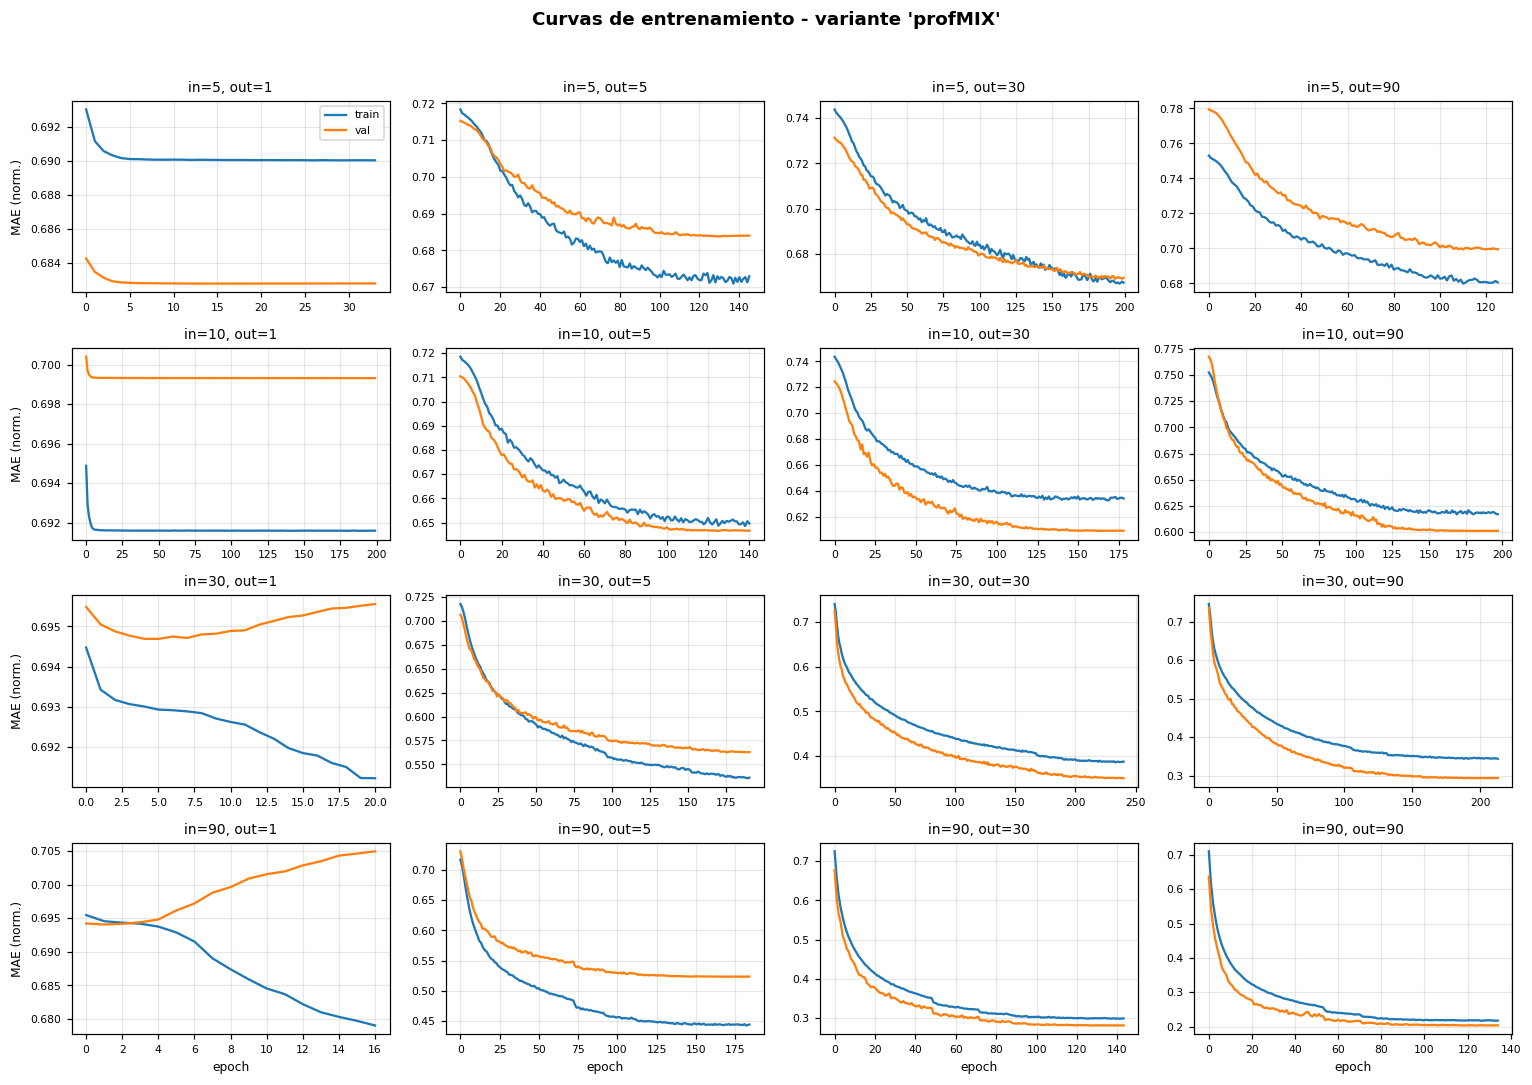

  guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixto_curvas_profMIX.png


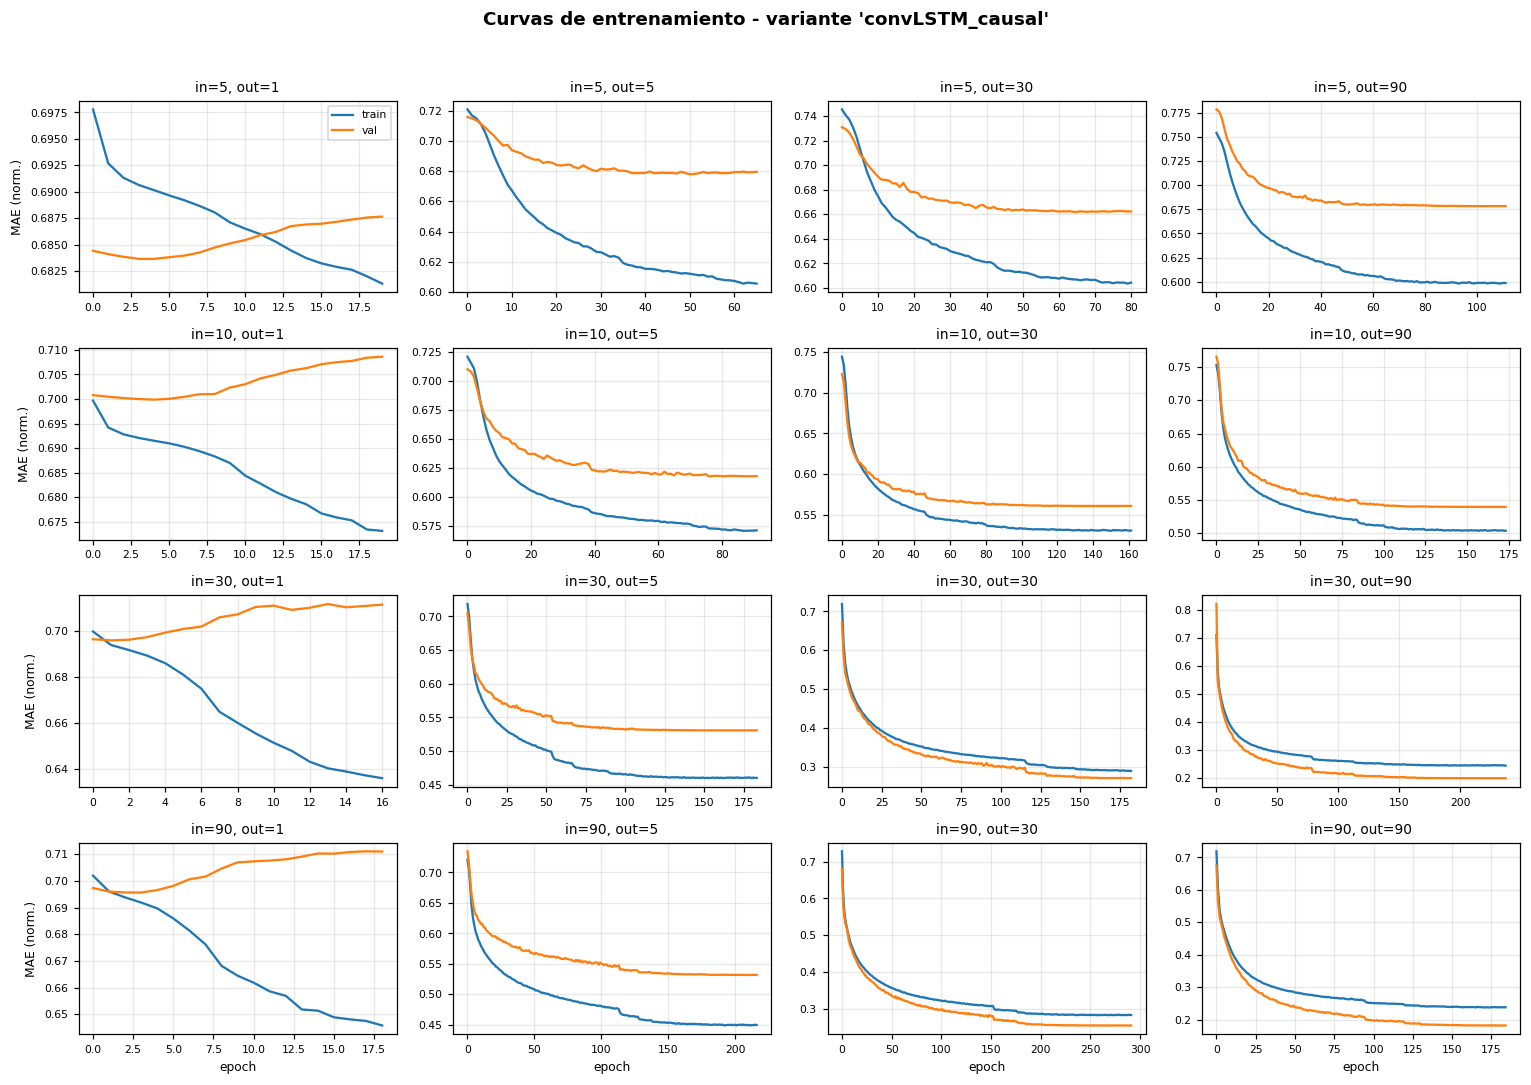

  guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixto_curvas_convLSTM_causal.png


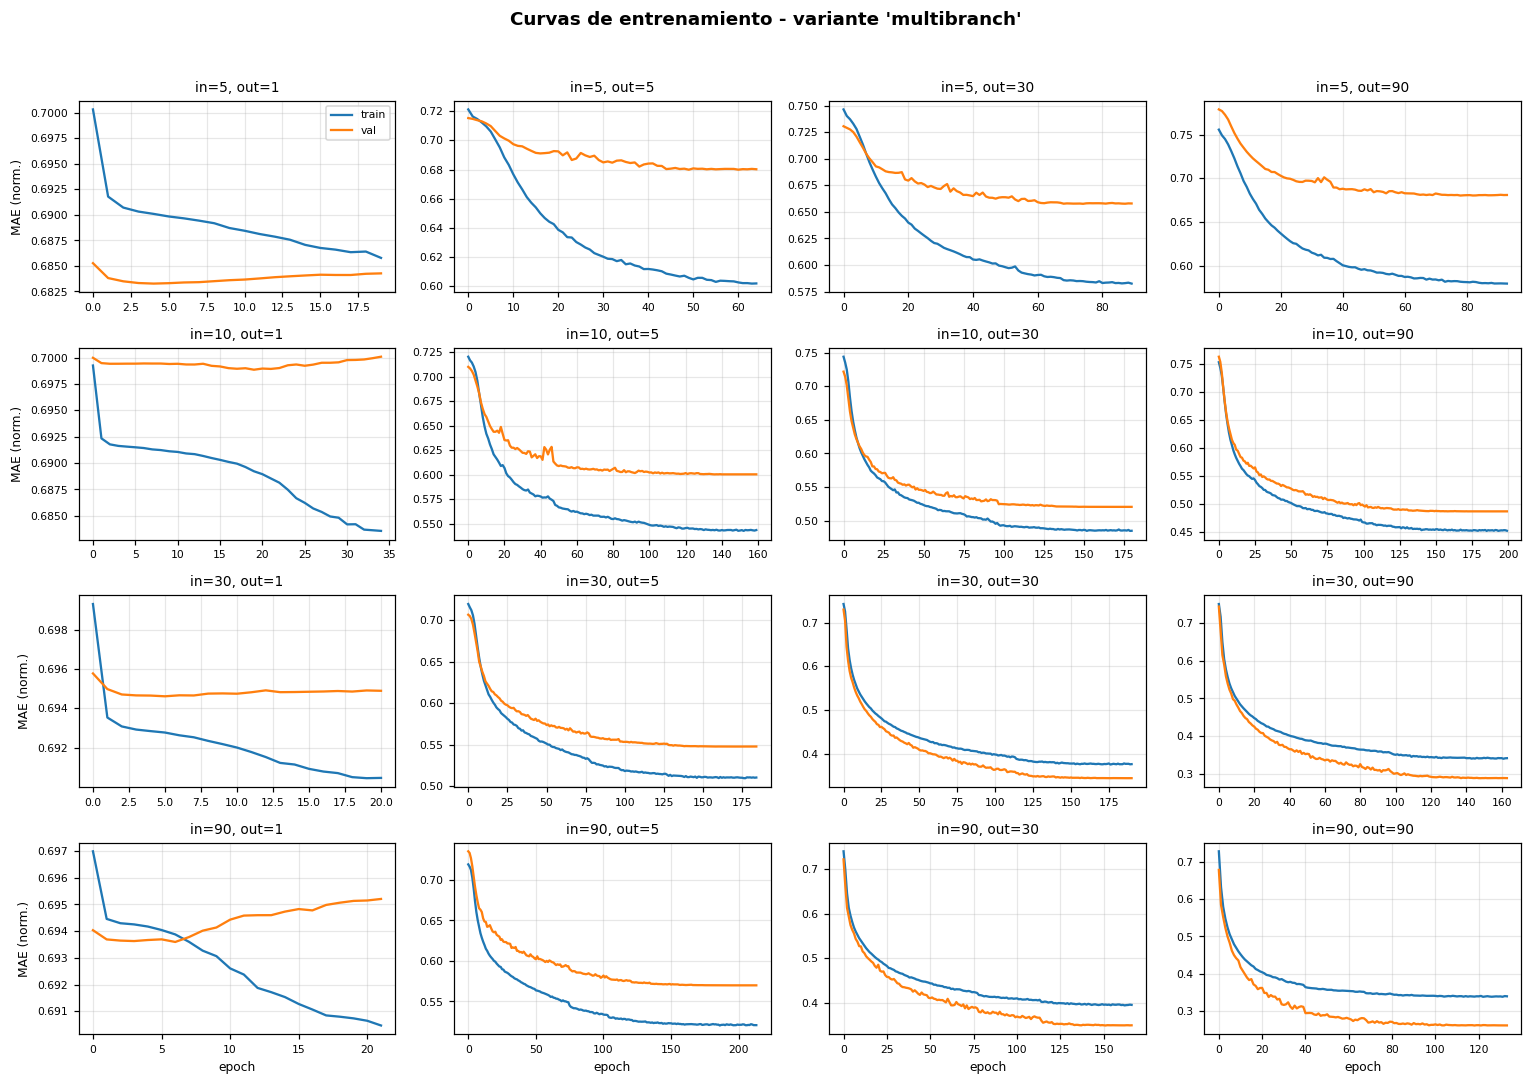

  guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixto_curvas_multibranch.png


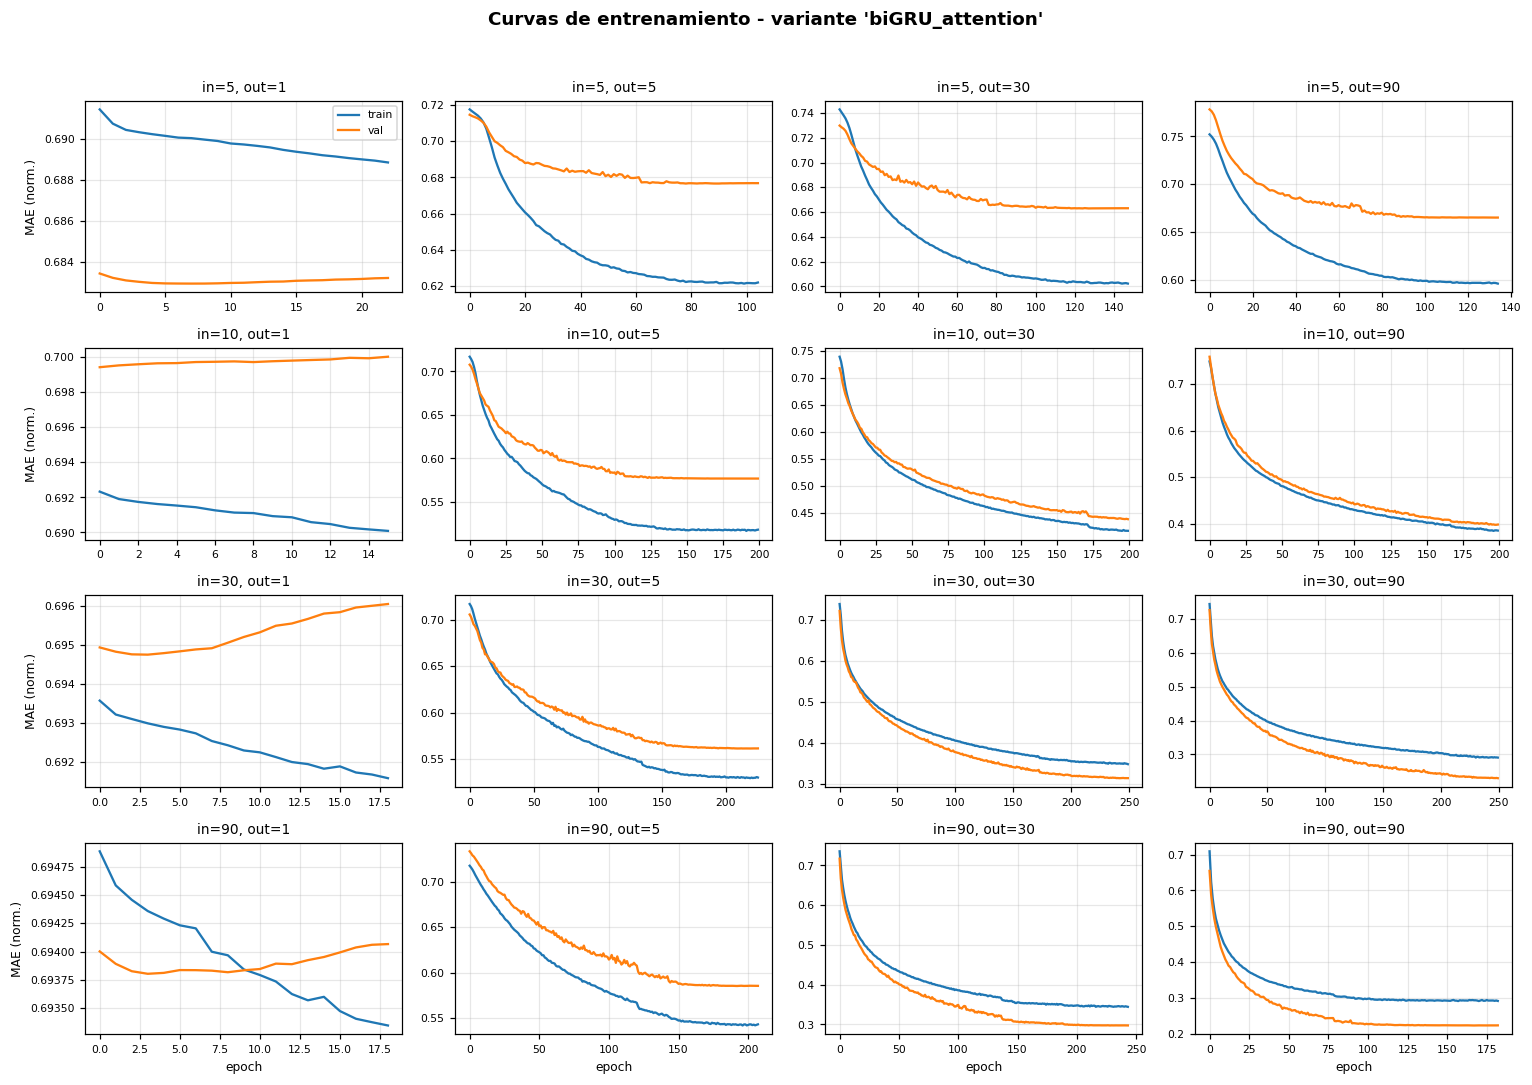

  guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixto_curvas_biGRU_attention.png


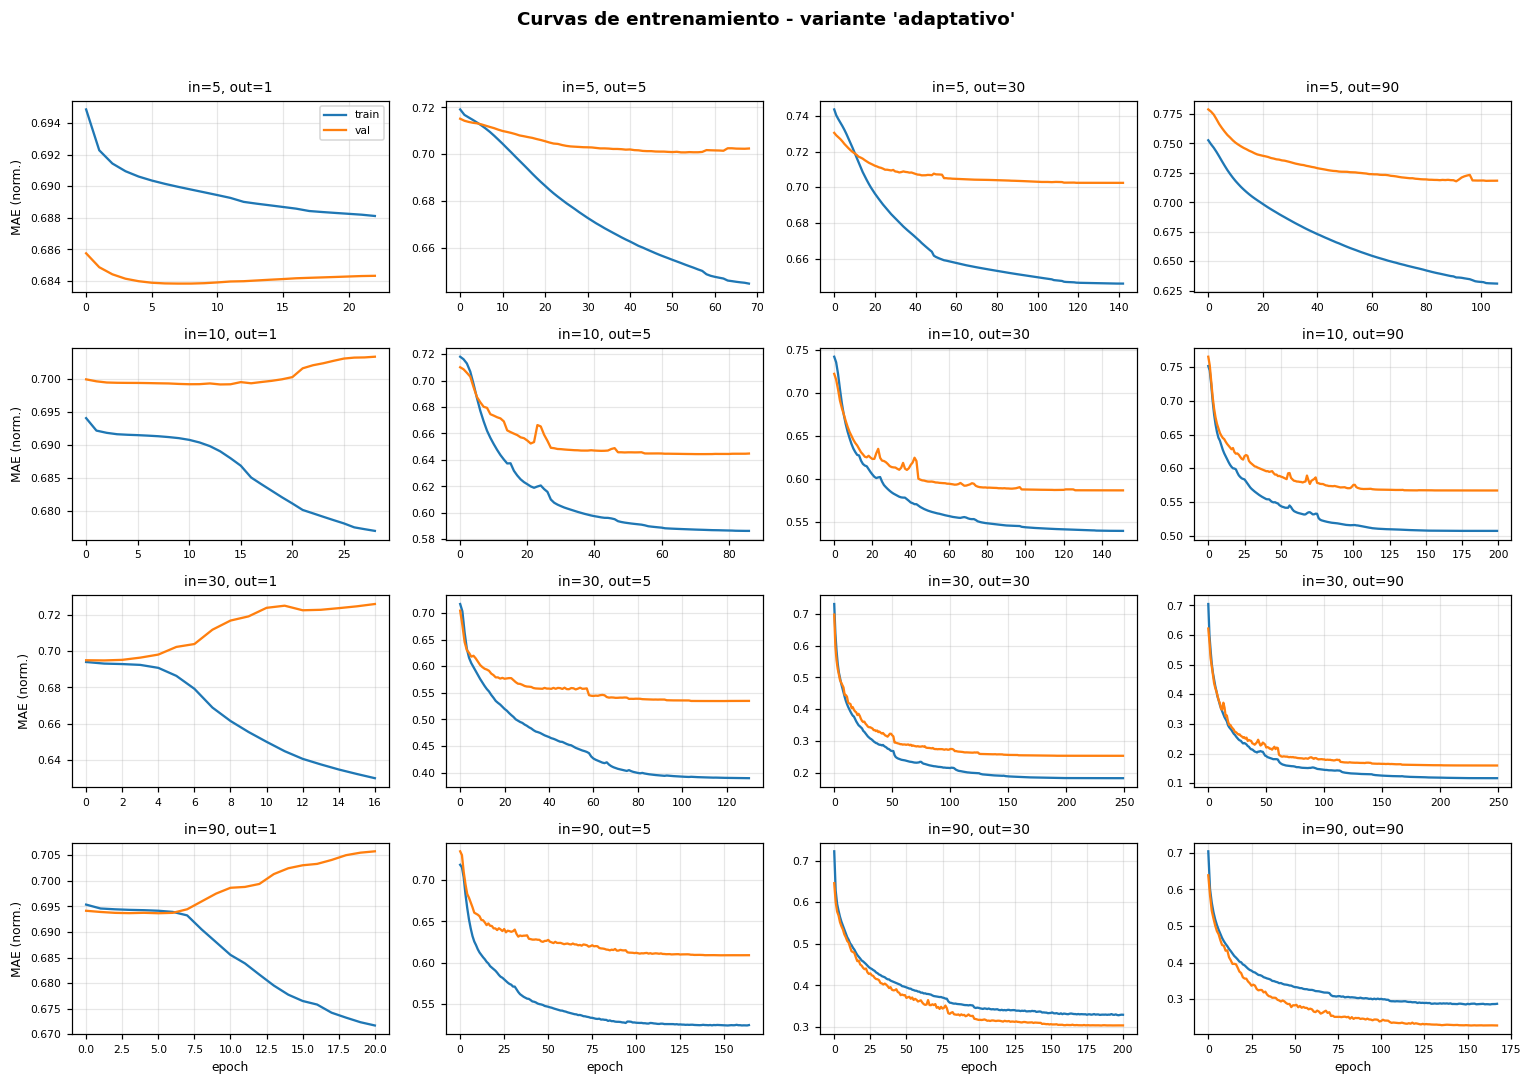

  guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixto_curvas_adaptativo.png


In [20]:
def plot_curves_grid(variante: str, histories: dict, save_path: Path) -> None:
    """Grid 4x4 con curvas loss/val_loss por (in_w, out_w)."""
    fig, axes = plt.subplots(
        nrows=len(INPUT_WINDOWS),
        ncols=len(OUTPUT_WINDOWS),
        figsize=(14, 10),
        sharex=False,
        sharey=False,
    )
    for i, in_w in enumerate(INPUT_WINDOWS):
        for j, out_w in enumerate(OUTPUT_WINDOWS):
            ax = axes[i, j]
            model_name = f"mixto_{variante}_in{in_w}_out{out_w}"
            h = histories.get(model_name)
            if h and "loss" in h:
                ax.plot(h["loss"], label="train", linewidth=1.5)
                ax.plot(h["val_loss"], label="val", linewidth=1.5)
            else:
                ax.text(0.5, 0.5, "(sin datos)", ha="center", va="center", transform=ax.transAxes, alpha=0.5)
            ax.set_title(f"in={in_w}, out={out_w}", fontsize=9)
            if i == len(INPUT_WINDOWS) - 1:
                ax.set_xlabel("epoch", fontsize=8)
            if j == 0:
                ax.set_ylabel("MAE (norm.)", fontsize=8)
            ax.tick_params(axis="both", labelsize=7)
            if i == 0 and j == 0:
                ax.legend(fontsize=7, loc="upper right")
    fig.suptitle(f"Curvas de entrenamiento - variante '{variante}'", fontsize=12, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


histories_loaded = _load_histories()
print(f"Historiales cargados: {len(histories_loaded)} modelos.")
if histories_loaded:
    for variante in VARIANTES:
        out_path = RESULTS_DIR / f"mixto_curvas_{variante}.png"
        plot_curves_grid(variante, histories_loaded, out_path)
        print(f"  guardado: {out_path}")

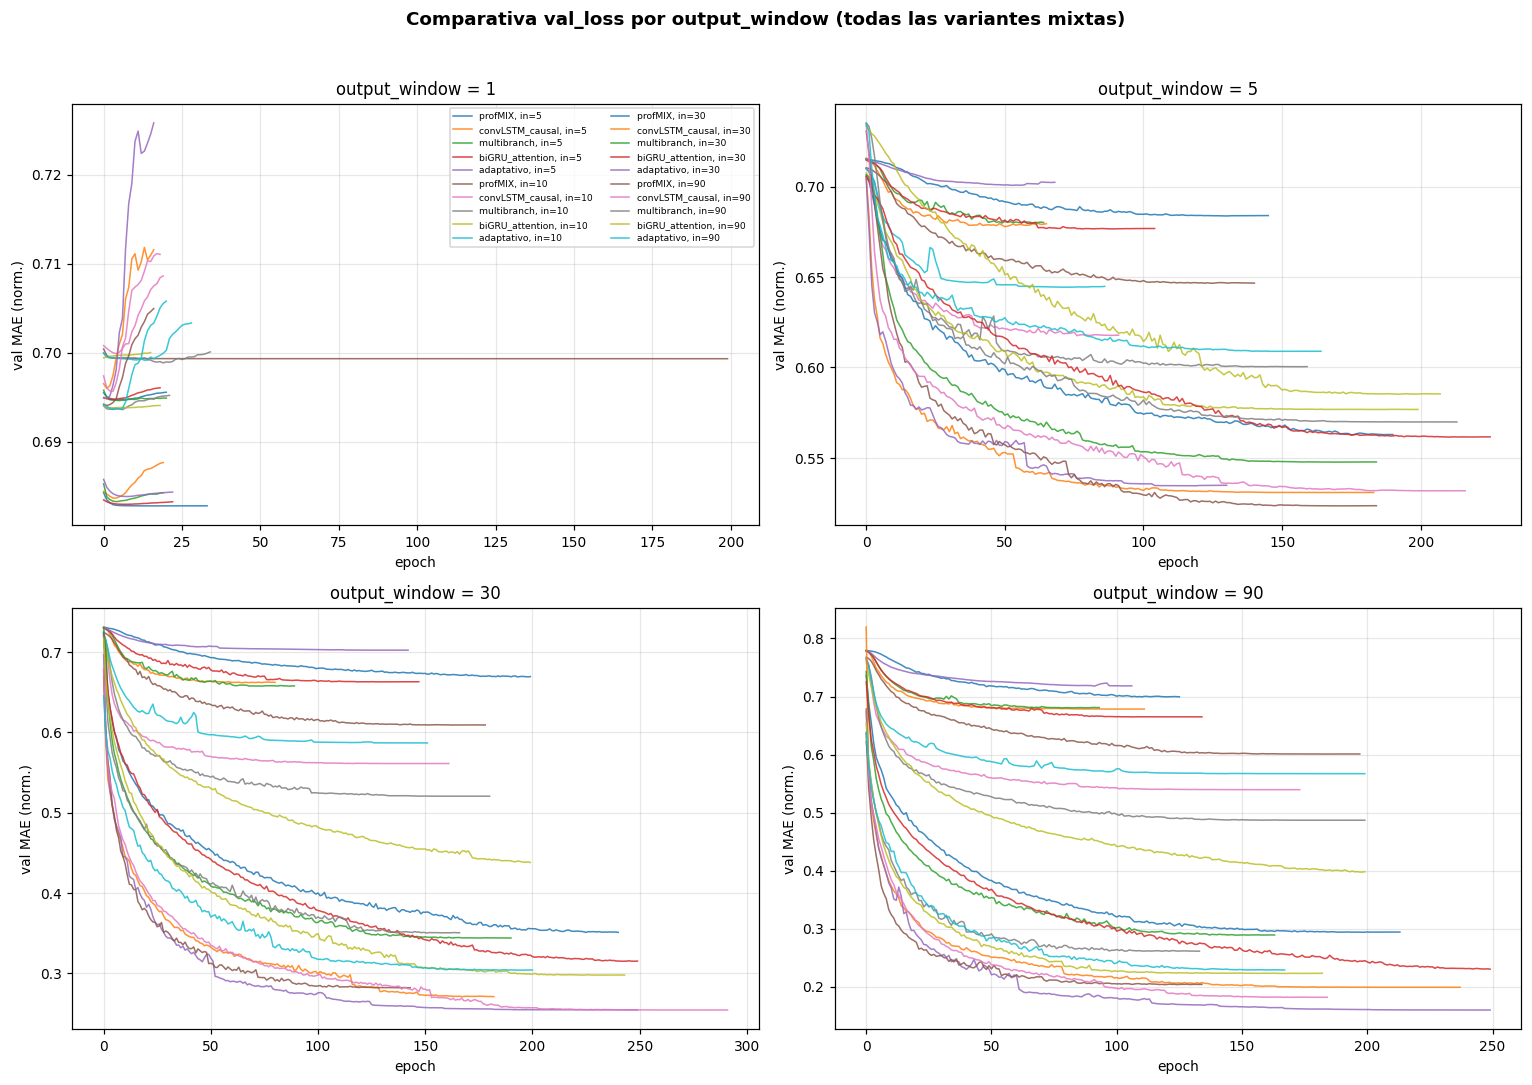

  guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixto_curvas_por_output.png


In [21]:
def plot_curves_combined_by_output(histories: dict, save_path: Path) -> None:
    """4 subplots (uno por output_window). Cada subplot muestra val_loss para todas las (in_w, variante)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    palette = plt.get_cmap("tab10")
    for idx, out_w in enumerate(OUTPUT_WINDOWS):
        ax = axes[idx]
        ci = 0
        for in_w in INPUT_WINDOWS:
            for variante in VARIANTES:
                model_name = f"mixto_{variante}_in{in_w}_out{out_w}"
                h = histories.get(model_name)
                if h and "val_loss" in h:
                    label = f"{variante}, in={in_w}"
                    ax.plot(h["val_loss"], label=label, linewidth=1.0, alpha=0.85, color=palette(ci % 10))
                ci += 1
        ax.set_title(f"output_window = {out_w}")
        ax.set_xlabel("epoch")
        ax.set_ylabel("val MAE (norm.)")
        if idx == 0:
            ax.legend(fontsize=6, ncol=2, loc="upper right")
    fig.suptitle("Comparativa val_loss por output_window (todas las variantes mixtas)", fontsize=12, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


if histories_loaded:
    plot_curves_combined_by_output(histories_loaded, RESULTS_DIR / "mixto_curvas_por_output.png")
    print(f"  guardado: {RESULTS_DIR / 'mixto_curvas_por_output.png'}")

## 10. Heatmaps de MAE en test

Tres niveles de análisis:

1. Un heatmap 4×4 (`input_window` × `output_window`) **por variante** (5 figs).
2. Un heatmap 4×4 con el **mejor mixto por celda** (mínimo de las 5 variantes).
3. Un heatmap 4×4 con **mejora porcentual vs MLP** (verde = mixto mejora; rojo = MLP era mejor).

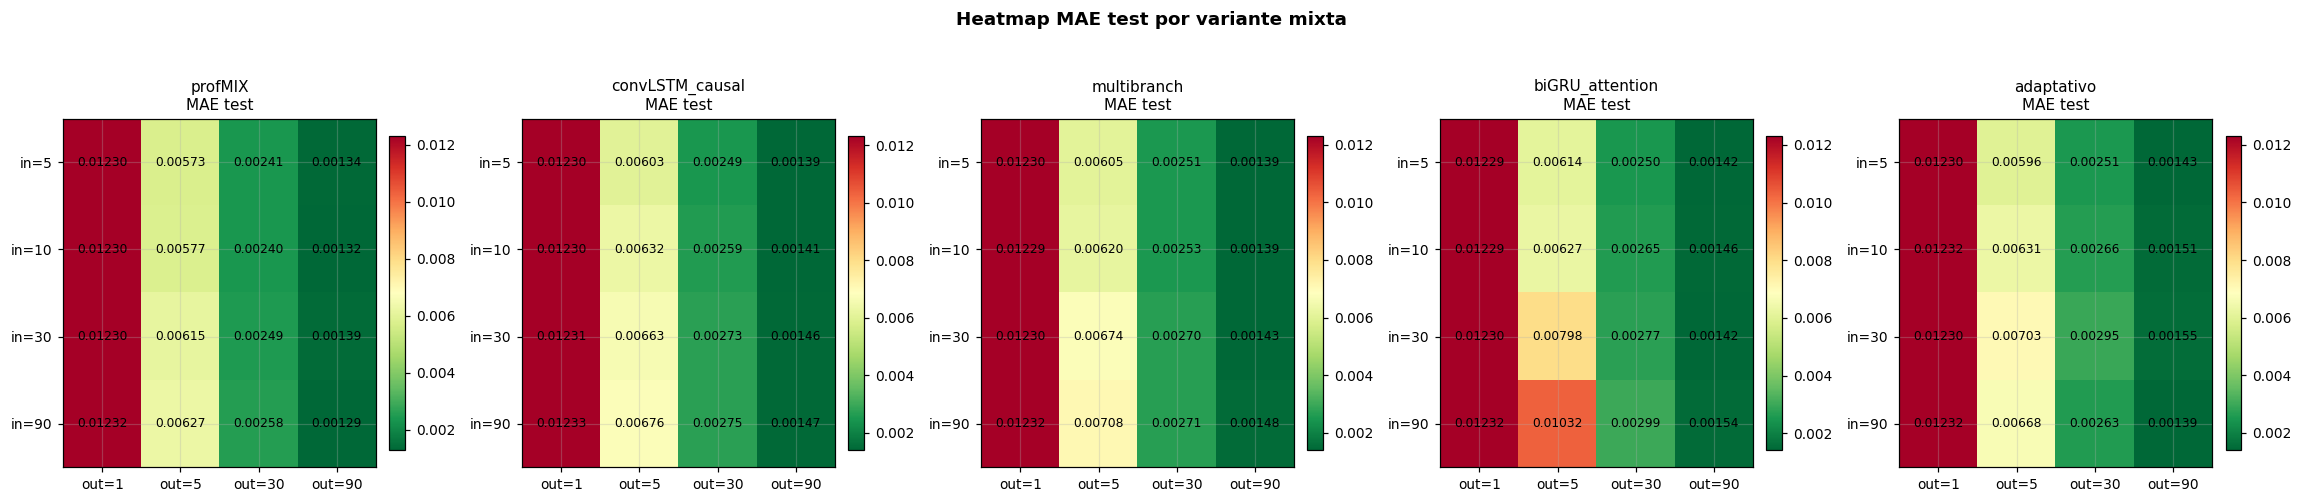

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixto_heatmap_por_variante.png


In [22]:
def heatmap_table(df_var: pd.DataFrame, value_col: str = "mae_test") -> pd.DataFrame:
    """Pivota a tabla input_window x output_window para un value_col."""
    pivot = df_var.pivot_table(index="input_window", columns="output_window", values=value_col, aggfunc="min")
    pivot = pivot.reindex(index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)
    return pivot


def render_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str = "{:.5f}", cmap: str = "RdYlGn_r", show_cbar: bool = True):
    data = pivot.values.astype(float)
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"out={c}" for c in pivot.columns], fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"in={r}" for r in pivot.index], fontsize=9)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            txt = "n/a" if np.isnan(v) else fmt.format(v)
            ax.text(j, i, txt, ha="center", va="center", fontsize=8, color="black")
    ax.set_title(title, fontsize=10)
    if show_cbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


if len(df_mix) > 0:
    fig, axes = plt.subplots(1, len(VARIANTES), figsize=(4.2 * len(VARIANTES), 4.6))
    for ax, variante in zip(axes, VARIANTES):
        sub = df_mix[df_mix["variante"] == variante]
        pivot = heatmap_table(sub, "mae_test")
        render_heatmap(ax, pivot, title=f"{variante}\nMAE test")
    fig.suptitle("Heatmap MAE test por variante mixta", fontsize=12, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(RESULTS_DIR / "mixto_heatmap_por_variante.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"guardado: {RESULTS_DIR / 'mixto_heatmap_por_variante.png'}")

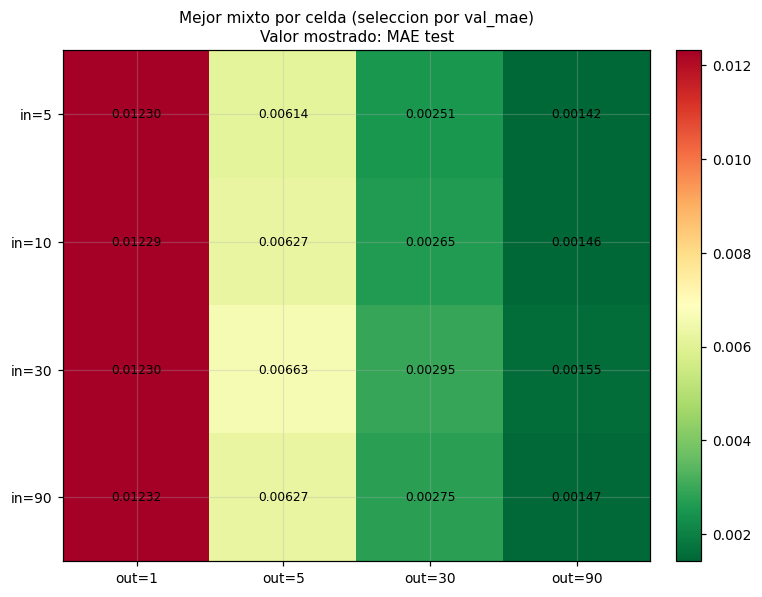

Variante ganadora por celda (seleccionada por val_mae):
output_window           1                5                30               90
input_window                                                                 
5                  profMIX  biGRU_attention      multibranch  biGRU_attention
10             multibranch  biGRU_attention  biGRU_attention  biGRU_attention
30             multibranch  convLSTM_causal       adaptativo       adaptativo
90             multibranch          profMIX  convLSTM_causal  convLSTM_causal


In [23]:
def best_per_cell(df: pd.DataFrame, by: str = "mae_val") -> pd.DataFrame:
    """Para cada (input_window, output_window) selecciona la fila con minimo `by` (ej: val_mae). Honesto: no toca test."""
    rows = []
    for in_w in INPUT_WINDOWS:
        for out_w in OUTPUT_WINDOWS:
            sub = df[(df["input_window"] == in_w) & (df["output_window"] == out_w)]
            if len(sub) == 0:
                continue
            best = sub.sort_values(by).iloc[0]
            rows.append(best)
    return pd.DataFrame(rows).reset_index(drop=True)


if len(df_mix) > 0:
    df_best_mix = best_per_cell(df_mix, by="mae_val")
    pivot_best_test = heatmap_table(df_best_mix, "mae_test")

    fig, ax = plt.subplots(figsize=(7, 5.5))
    render_heatmap(ax, pivot_best_test, title="Mejor mixto por celda (seleccion por val_mae)\nValor mostrado: MAE test", cmap="RdYlGn_r")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "mixto_heatmap_mejor.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    pivot_winner = df_best_mix.pivot_table(index="input_window", columns="output_window", values="variante", aggfunc="first")
    pivot_winner = pivot_winner.reindex(index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)
    print("Variante ganadora por celda (seleccionada por val_mae):")
    print(pivot_winner)

In [24]:
def load_baseline_csv(path: Path):
    """Carga un CSV de baseline si existe (admite tanto results/ como ../results/). Devuelve DataFrame o None."""
    if path.exists():
        return pd.read_csv(path)
    alt = (Path("..") / "results" / path.name).resolve()
    if alt.exists():
        return pd.read_csv(alt)
    return None


df_mlp = load_baseline_csv(RESULTS_DIR / "mlp_resultados.csv")
df_lin = load_baseline_csv(RESULTS_DIR / "regresion_lineal_resultados.csv")
df_bh = load_baseline_csv(RESULTS_DIR / "buy_and_hold_resultados.csv")

print(f"MLP   resultados : {'OK' if df_mlp is not None else 'NO DISPONIBLE'}")
print(f"Lineal resultados: {'OK' if df_lin is not None else 'NO DISPONIBLE'}")
print(f"B&H resultados   : {'OK' if df_bh is not None else 'NO DISPONIBLE'}")

MLP   resultados : OK
Lineal resultados: OK
B&H resultados   : OK


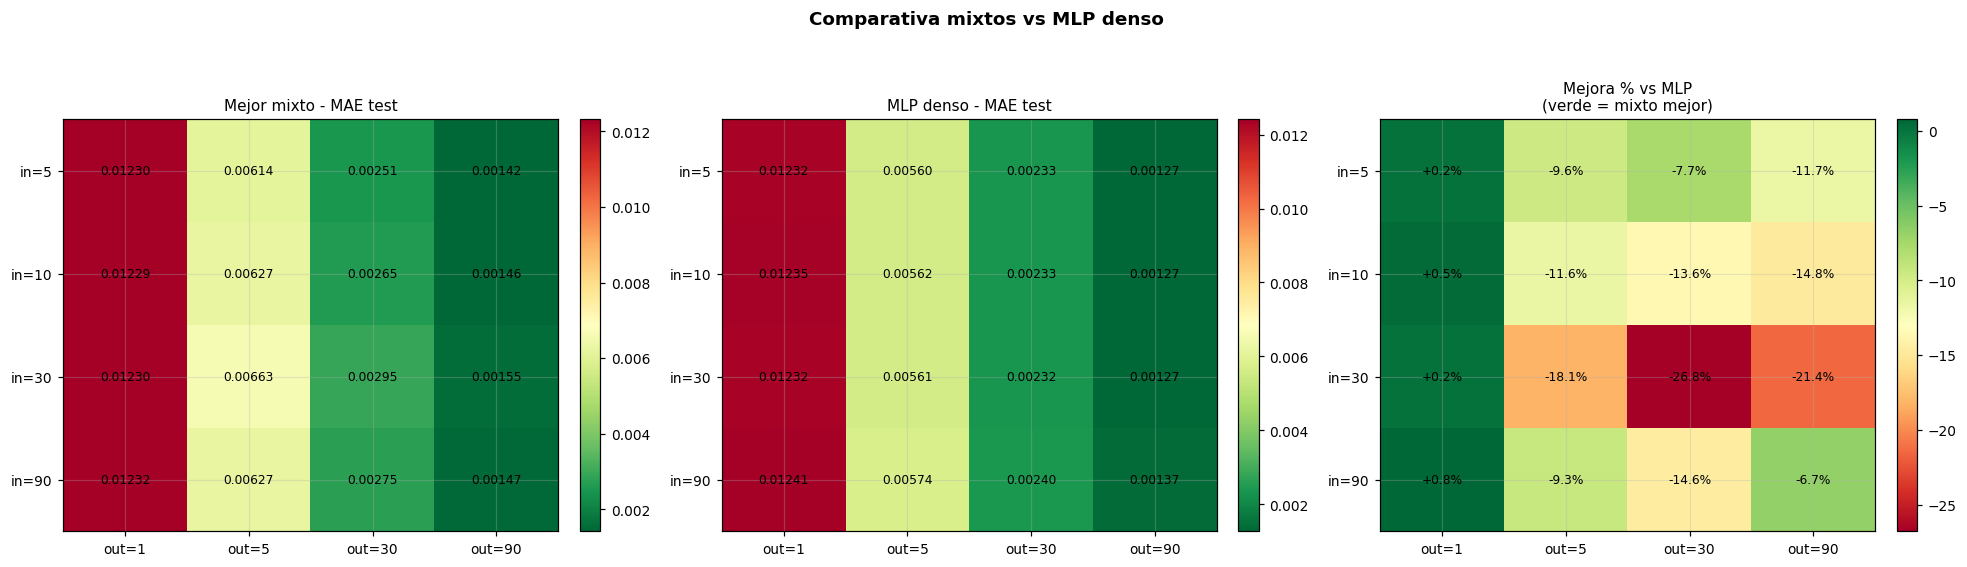

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixto_heatmap_mejora_vs_mlp.png
Mixtos baten al MLP en 4/16 celdas. Mejora media : -10.27%


In [25]:
if len(df_mix) > 0 and df_mlp is not None:
    pivot_mix = heatmap_table(df_best_mix, "mae_test")
    pivot_mlp = df_mlp.pivot_table(index="input_window", columns="output_window", values="mae_test", aggfunc="min")
    pivot_mlp = pivot_mlp.reindex(index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)
    pct_improvement = (pivot_mlp - pivot_mix) / pivot_mlp * 100.0

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
    render_heatmap(axes[0], pivot_mix, title="Mejor mixto - MAE test", fmt="{:.5f}", cmap="RdYlGn_r")
    render_heatmap(axes[1], pivot_mlp, title="MLP denso - MAE test", fmt="{:.5f}", cmap="RdYlGn_r")
    render_heatmap(axes[2], pct_improvement, title="Mejora % vs MLP\n(verde = mixto mejor)", fmt="{:+.1f}%", cmap="RdYlGn")
    fig.suptitle("Comparativa mixtos vs MLP denso", fontsize=12, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(RESULTS_DIR / "mixto_heatmap_mejora_vs_mlp.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"guardado: {RESULTS_DIR / 'mixto_heatmap_mejora_vs_mlp.png'}")
    n_cells = pct_improvement.size
    n_better = int((pct_improvement > 0).sum().sum())
    print(f"Mixtos baten al MLP en {n_better}/{n_cells} celdas. Mejora media : {pct_improvement.mean().mean():+.2f}%")

## 11. Matriz de competición (mejor modelo por celda)

Esta es la tabla obligatoria del enunciado: **una matriz `#ventanas_entrada × #ventanas_salida` con los resultados en test del mejor modelo para cada combinación**.

La selección del "mejor" se hace por **`val_mae`** (decisión SIEMPRE tomada con validación, **nunca con test**). Después se reporta el `mae_test` de ese modelo.

In [26]:
def build_competition_matrix(df_mix, df_mlp, df_lin, df_bh):
    """Construye la matriz competicion: para cada celda, el mejor modelo de TODAS las familias por mae_val.

    Si df_lin/df_bh no tienen mae_val (Buy&Hold tipicamente no), se usa mae_test solo para esos baselines.
    """
    rows = []
    for in_w in INPUT_WINDOWS:
        for out_w in OUTPUT_WINDOWS:
            candidates = []
            if df_mix is not None and len(df_mix) > 0:
                sub = df_mix[(df_mix["input_window"] == in_w) & (df_mix["output_window"] == out_w)]
                for _, r in sub.iterrows():
                    candidates.append(("mixto_" + r["variante"], r["mae_val"], r["mae_test"], r["n_params"]))
            if df_mlp is not None:
                sub = df_mlp[(df_mlp["input_window"] == in_w) & (df_mlp["output_window"] == out_w)]
                for _, r in sub.iterrows():
                    candidates.append(("mlp_denso", r.get("mae_val", np.nan), r["mae_test"], r.get("n_params", np.nan)))
            if df_lin is not None:
                sub = df_lin[(df_lin["input_window"] == in_w) & (df_lin["output_window"] == out_w)]
                for _, r in sub.iterrows():
                    candidates.append(("regresion_lineal", r.get("mae_val", np.nan), r["mae_test"], r.get("n_params", np.nan)))
            if df_bh is not None:
                sub = df_bh[(df_bh["input_window"] == in_w) & (df_bh["output_window"] == out_w)]
                for _, r in sub.iterrows():
                    candidates.append(("buy_and_hold", r.get("mae_val", np.nan), r["mae_test"], np.nan))
            if not candidates:
                continue
            with_val = [c for c in candidates if not (isinstance(c[1], float) and np.isnan(c[1]))]
            ranked = sorted(with_val, key=lambda c: c[1]) if with_val else sorted(candidates, key=lambda c: c[2])
            top = ranked[0]
            rows.append({
                "input_window": in_w,
                "output_window": out_w,
                "modelo_ganador": top[0],
                "mae_val_ganador": top[1],
                "mae_test_ganador": top[2],
                "n_params_ganador": top[3],
            })
    return pd.DataFrame(rows)


df_competicion = build_competition_matrix(df_mix, df_mlp, df_lin, df_bh)
if len(df_competicion) > 0:
    print("Matriz de competicion (seleccion por mae_val cuando disponible):")
    print(df_competicion.to_string(index=False))
    df_competicion.to_csv(RESULTS_DIR / "matriz_competicion.csv", index=False)
    print(f"guardado: {RESULTS_DIR / 'matriz_competicion.csv'}")

Matriz de competicion (seleccion por mae_val cuando disponible):
 input_window  output_window        modelo_ganador  mae_val_ganador  mae_test_ganador  n_params_ganador
            5              1         mixto_profMIX         0.011434          0.012296             15303
            5              5 mixto_biGRU_attention         0.005036          0.006138             20807
            5             30     mixto_multibranch         0.001911          0.002506             20823
            5             90 mixto_biGRU_attention         0.001084          0.001418             20807
           10              1     mixto_multibranch         0.011647          0.012288             28055
           10              5 mixto_biGRU_attention         0.004299          0.006270             77015
           10             30 mixto_biGRU_attention         0.001276          0.002648             77015
           10             90 mixto_biGRU_attention         0.000651          0.001459             77015

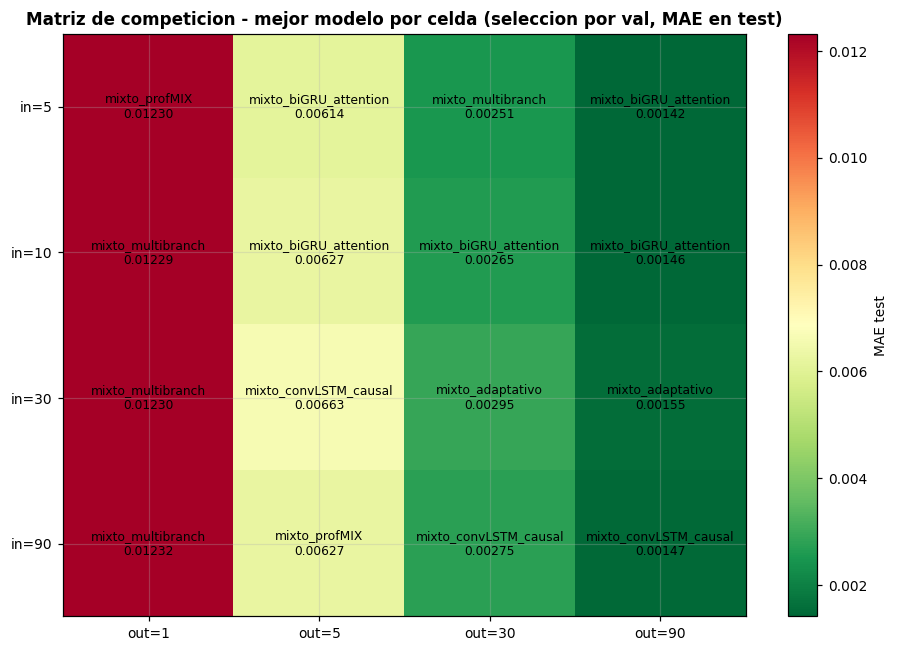

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\matriz_competicion.png


In [27]:
if len(df_competicion) > 0:
    pivot_test = df_competicion.pivot(index="input_window", columns="output_window", values="mae_test_ganador")
    pivot_test = pivot_test.reindex(index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)
    pivot_winner = df_competicion.pivot(index="input_window", columns="output_window", values="modelo_ganador")
    pivot_winner = pivot_winner.reindex(index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)

    fig, ax = plt.subplots(figsize=(8.5, 6))
    data = pivot_test.values.astype(float)
    im = ax.imshow(data, aspect="auto", cmap="RdYlGn_r")
    ax.set_xticks(range(len(OUTPUT_WINDOWS)))
    ax.set_xticklabels([f"out={c}" for c in OUTPUT_WINDOWS])
    ax.set_yticks(range(len(INPUT_WINDOWS)))
    ax.set_yticklabels([f"in={r}" for r in INPUT_WINDOWS])
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            modelo = pivot_winner.iloc[i, j]
            ax.text(j, i, f"{modelo}\n{v:.5f}" if not np.isnan(v) else "n/a", ha="center", va="center", fontsize=8)
    ax.set_title("Matriz de competicion - mejor modelo por celda (seleccion por val, MAE en test)", fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, label="MAE test")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "matriz_competicion.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"guardado: {RESULTS_DIR / 'matriz_competicion.png'}")

## 12. Deep dive — combinación (`input_window=90`, `output_window=90`)

Esta es la combinación que se usará para construir las **carteras 2025** (notebook `08_carteras_2025.ipynb`). Por eso le dedicamos un mini-protocolo de tuning **honesto y defendible**:

### Protocolo

1. Definimos un **grid pequeño** de hiperparámetros por variante (learning rate, batch size, units principales).
2. Para cada hiper, hacemos **3-fold temporal** (TimeSeries-style) **dentro del bloque train+val pre-existente**. El test queda intacto.
3. Promediamos `mae_val_kfold` y elegimos el mejor hiper por variante.
4. Reentrenamos cada ganador en el `train` completo con `val` como early-stopping.
5. **Ensemble top-3**: promedio simple de las predicciones (no aprende pesos -> no introduce variabilidad nueva).
6. Evaluamos el ensemble **una sola vez** en `test`.

```mermaid
flowchart TD
    A[X, y para 90,90] --> B[split_triple -> train, val, test]
    B --> C[Solo train+val para tuning]
    C --> D[3-fold temporal por variante x hiper]
    D --> E[Promedio mae_val_kfold]
    E --> F[Mejor hiper por variante]
    F --> G[Reentrenar en train con early stop en val]
    G --> H[Top-3 variantes por mae_val final]
    H --> I[Ensemble: promedio de predicciones]
    I --> J[Una sola evaluacion en test]
    J --> K[Reportar: top-1 individual, top-3 individual, ensemble]
```

### Por qué es defendible

- El test **no se usa nunca** para elegir hiperparámetros, ni siquiera para deshacer el ensemble.
- El `mae_val` es el del split estándar (idéntico a competición), así que el "best by val" sigue siendo comparable con el resto del notebook.
- El ensemble es promedio simple (no aprende), no añade parámetros entrenables ni grados de libertad nuevos sobre el test.

In [28]:
DEEPDIVE_IN = 90
DEEPDIVE_OUT = 90

GRID_HYPERS = {
    "lr": [3e-4, 5e-4, 1e-3],
    "batch_size": [32, 64],
}

mae_ensemble = None
ensemble_predictions_test = []
ensemble_models_info = []
deepdive_best_by_variante = {}
deepdive_results = []
deepdive_finals = []


def make_temporal_folds(n: int, k: int = 3):
    """Divide [0..n-1] en k folds temporales contiguos. Devuelve lista de (idx_train, idx_val).

    Cada fold usa los primeros bloques como train y el siguiente como val (esquema 'expanding window').
    """
    fold_size = n // (k + 1)
    folds = []
    for i in range(1, k + 1):
        train_end = fold_size * i
        val_end = fold_size * (i + 1) if i < k else n
        idx_train = np.arange(0, train_end)
        idx_val = np.arange(train_end, val_end)
        folds.append((idx_train, idx_val))
    return folds


def train_one_fold(variante, in_w, out_w, X_tr, y_tr, X_va, y_va, scaler_X, scaler_y, lr, batch_size, epochs):
    """Entrena UN modelo en UN fold. Devuelve mae_val real."""
    tf.keras.backend.clear_session()
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)

    X_tr_n = apply_scaler_X(scaler_X, X_tr)
    X_va_n = apply_scaler_X(scaler_X, X_va)
    y_tr_n = apply_scaler_y(scaler_y, y_tr)
    y_va_n = apply_scaler_y(scaler_y, y_va)

    model = VARIANTES[variante](in_w, out_w, n_assets=N_ASSETS)
    model.compile(optimizer=Adam(learning_rate=lr), loss="mae", metrics=["mae"])
    cb = [
        EarlyStopping(monitor="val_mae", patience=10, restore_best_weights=True, mode="min"),
        ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=4, min_lr=1e-6, mode="min"),
        TerminateOnNaN(),
    ]
    model.fit(
        X_tr_n,
        y_tr_n,
        validation_data=(X_va_n, y_va_n),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=0,
        shuffle=True,
    )
    pred = inverse_y(scaler_y, model.predict(X_va_n, verbose=0))
    return mae(y_va, pred)

In [29]:
RUN_DEEPDIVE = True
DEEPDIVE_K_FOLDS = 3
DEEPDIVE_EPOCHS = 80

if RUN_DEEPDIVE:
    in_w, out_w = DEEPDIVE_IN, DEEPDIVE_OUT
    print(f"Deep dive sobre (in={in_w}, out={out_w}). K={DEEPDIVE_K_FOLDS} folds temporales internos.")
    print()

    X_dd, y_dd = create_time_series_data(returns_df, in_w, out_w)
    X_train, X_val, X_test, y_train, y_val, y_test = split_triple(X_dd, y_dd)

    X_train_full = np.concatenate([X_train, X_val], axis=0)
    y_train_full = np.concatenate([y_train, y_val], axis=0)
    print(f"X_train_full {X_train_full.shape}    X_test {X_test.shape}")
    print()

    folds = make_temporal_folds(len(X_train_full), k=DEEPDIVE_K_FOLDS)

    for variante in VARIANTES:
        print(f"\n--- Variante: {variante} ---")
        best_score = float("inf")
        best_hyper = None
        for lr in GRID_HYPERS["lr"]:
            for bs in GRID_HYPERS["batch_size"]:
                fold_scores = []
                for fi, (idx_tr, idx_va) in enumerate(folds):
                    X_tr_f = X_train_full[idx_tr]
                    y_tr_f = y_train_full[idx_tr]
                    X_va_f = X_train_full[idx_va]
                    y_va_f = y_train_full[idx_va]

                    scaler_X_f, scaler_y_f = fit_scalers(X_tr_f, y_tr_f)
                    score = train_one_fold(
                        variante, in_w, out_w,
                        X_tr_f, y_tr_f, X_va_f, y_va_f,
                        scaler_X_f, scaler_y_f,
                        lr=lr, batch_size=bs, epochs=DEEPDIVE_EPOCHS,
                    )
                    fold_scores.append(score)

                mean_score = float(np.mean(fold_scores))
                std_score = float(np.std(fold_scores))
                deepdive_results.append({
                    "variante": variante, "lr": lr, "batch_size": bs,
                    "mae_val_kfold_mean": mean_score, "mae_val_kfold_std": std_score,
                    "fold_scores": fold_scores,
                })
                print(f"  lr={lr:.4f}  bs={bs:>3d}  ->  mae_val_kfold = {mean_score:.6f} +/- {std_score:.6f}  folds={[f'{s:.5f}' for s in fold_scores]}")

                if mean_score < best_score:
                    best_score = mean_score
                    best_hyper = {"lr": lr, "batch_size": bs}

        deepdive_best_by_variante[variante] = {
            "hyper": best_hyper,
            "mae_val_kfold_mean": best_score,
        }
        print(f"  >> Mejor para {variante}: {best_hyper}  (mae_val_kfold={best_score:.6f})")

    pd.DataFrame(deepdive_results).to_csv(RESULTS_DIR / "mixto_deepdive_grid.csv", index=False)
    print()
    print(f"guardado: {RESULTS_DIR / 'mixto_deepdive_grid.csv'}")
else:
    print("RUN_DEEPDIVE=False -> saltando esta seccion.")

Deep dive sobre (in=90, out=90). K=3 folds temporales internos.

X_train_full (14418, 90, 23)    X_test (1603, 90, 23)


--- Variante: profMIX ---
  lr=0.0003  bs= 32  ->  mae_val_kfold = 0.000441 +/- 0.000069  folds=['0.00053', '0.00042', '0.00037']
  lr=0.0003  bs= 64  ->  mae_val_kfold = 0.000481 +/- 0.000089  folds=['0.00060', '0.00045', '0.00039']
  lr=0.0005  bs= 32  ->  mae_val_kfold = 0.000405 +/- 0.000053  folds=['0.00048', '0.00038', '0.00035']
  lr=0.0005  bs= 64  ->  mae_val_kfold = 0.000424 +/- 0.000071  folds=['0.00052', '0.00040', '0.00036']
  lr=0.0010  bs= 32  ->  mae_val_kfold = 0.000402 +/- 0.000052  folds=['0.00047', '0.00038', '0.00035']
  lr=0.0010  bs= 64  ->  mae_val_kfold = 0.000400 +/- 0.000055  folds=['0.00047', '0.00038', '0.00034']
  >> Mejor para profMIX: {'lr': 0.001, 'batch_size': 64}  (mae_val_kfold=0.000400)

--- Variante: convLSTM_causal ---
  lr=0.0003  bs= 32  ->  mae_val_kfold = 0.000486 +/- 0.000081  folds=['0.00059', '0.00047', '0.00040']
  lr=0.

In [30]:
if RUN_DEEPDIVE and deepdive_best_by_variante:
    in_w, out_w = DEEPDIVE_IN, DEEPDIVE_OUT
    X_dd, y_dd = create_time_series_data(returns_df, in_w, out_w)
    X_train, X_val, X_test, y_train, y_val, y_test = split_triple(X_dd, y_dd)
    scaler_X, scaler_y = fit_scalers(X_train, y_train)
    X_train_n = apply_scaler_X(scaler_X, X_train)
    X_val_n = apply_scaler_X(scaler_X, X_val)
    X_test_n = apply_scaler_X(scaler_X, X_test)
    y_train_n = apply_scaler_y(scaler_y, y_train)
    y_val_n = apply_scaler_y(scaler_y, y_val)

    print(f"Reentrenando los ganadores de cada variante para (in={in_w}, out={out_w})")
    print()

    for variante, info in deepdive_best_by_variante.items():
        hp = info["hyper"]
        tf.keras.backend.clear_session()
        np.random.seed(RANDOM_SEED)
        tf.random.set_seed(RANDOM_SEED)

        model_path = MODELS_DIR / f"mixto_dd_{variante}_in{in_w}_out{out_w}.keras"
        log_path = LOGS_DIR / f"mixto_dd_{variante}_in{in_w}_out{out_w}.csv"

        model = VARIANTES[variante](in_w, out_w, n_assets=N_ASSETS)
        model.compile(optimizer=Adam(learning_rate=hp["lr"]), loss="mae", metrics=["mae"])
        cb = make_callbacks(model_path, log_path, monitor="val_mae")

        t0 = time.time()
        h = model.fit(
            X_train_n, y_train_n,
            validation_data=(X_val_n, y_val_n),
            epochs=MAX_EPOCHS[in_w],
            batch_size=hp["batch_size"],
            callbacks=cb,
            verbose=0,
            shuffle=True,
        )
        elapsed = time.time() - t0

        if model_path.exists():
            try:
                m = load_model(model_path, compile=False)
                m.compile(optimizer=Adam(learning_rate=hp["lr"]), loss="mae", metrics=["mae"])
                model = m
            except Exception:
                pass

        pred_val = inverse_y(scaler_y, model.predict(X_val_n, verbose=0))
        pred_test = inverse_y(scaler_y, model.predict(X_test_n, verbose=0))
        mv = mae(y_val, pred_val)
        mt = mae(y_test, pred_test)
        deepdive_finals.append({
            "variante": variante, "lr": hp["lr"], "batch_size": hp["batch_size"],
            "mae_val": mv, "mae_test": mt,
            "epochs_entrenadas": len(h.history.get("loss", [])),
            "n_params": int(model.count_params()),
            "elapsed_sec": round(elapsed, 1),
            "model_path": str(model_path),
        })
        ensemble_predictions_test.append(pred_test)
        ensemble_models_info.append((variante, mv))
        print(f"  {variante:18s}  lr={hp['lr']:.4f} bs={hp['batch_size']:>3d}  val={mv:.6f}  test={mt:.6f}  params={model.count_params():,}  t={elapsed:.1f}s")

    df_dd_finals = pd.DataFrame(deepdive_finals).sort_values("mae_val")
    df_dd_finals.to_csv(RESULTS_DIR / "mixto_deepdive_finals.csv", index=False)
    print()
    print(df_dd_finals.to_string(index=False))

Reentrenando los ganadores de cada variante para (in=90, out=90)

  profMIX             lr=0.0010 bs= 64  val=0.000318  test=0.001277  params=120,983  t=1064.0s
  convLSTM_causal     lr=0.0010 bs= 32  val=0.000277  test=0.001480  params=56,023  t=1311.5s
  multibranch         lr=0.0005 bs= 32  val=0.000407  test=0.001399  params=54,103  t=683.8s
  biGRU_attention     lr=0.0010 bs= 32  val=0.000295  test=0.001420  params=109,975  t=1557.8s
  adaptativo          lr=0.0010 bs= 32  val=0.000353  test=0.001344  params=79,959  t=1059.5s

       variante     lr  batch_size  mae_val  mae_test  epochs_entrenadas  n_params  elapsed_sec                                                                                                             model_path
convLSTM_causal 0.0010          32 0.000277  0.001480                198     56023       1311.5 C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\models\mixto_dd_convLSTM_causal_in90_out90.keras
biGRU_attention 0.0010          

In [31]:
if RUN_DEEPDIVE and len(ensemble_predictions_test) >= 3:
    in_w, out_w = DEEPDIVE_IN, DEEPDIVE_OUT
    X_dd, y_dd = create_time_series_data(returns_df, in_w, out_w)
    _, _, X_test, _, _, y_test = split_triple(X_dd, y_dd)

    ranked = sorted(zip(ensemble_models_info, ensemble_predictions_test), key=lambda t: t[0][1])
    top_k = 3
    top_models = ranked[:top_k]
    top_names = [t[0][0] for t in top_models]
    top_preds = [t[1] for t in top_models]
    ensemble_pred = np.mean(np.stack(top_preds, axis=0), axis=0)
    mae_ensemble = mae(y_test, ensemble_pred)

    individuales = pd.DataFrame(deepdive_finals).sort_values("mae_test")
    print("Resultado deep dive (90, 90)")
    print("============================")
    print(f"Top-{top_k} variantes elegidas POR mae_val: {top_names}")
    print(f"MAE test ensemble (promedio simple top-3) : {mae_ensemble:.6f}")
    print()
    print("MAE test individuales:")
    for r in individuales.itertuples(index=False):
        marca = "  <- ensemble" if r.variante in top_names else ""
        print(f"  {r.variante:18s}  test={r.mae_test:.6f}  val={r.mae_val:.6f}{marca}")

    if df_mlp is not None:
        sub_mlp = df_mlp[(df_mlp["input_window"] == in_w) & (df_mlp["output_window"] == out_w)]
        if len(sub_mlp) > 0:
            mae_mlp = float(sub_mlp.iloc[0]["mae_test"])
            mejora_pct = (mae_mlp - mae_ensemble) / mae_mlp * 100
            print(f"\nReferencia MLP denso para (90,90): {mae_mlp:.6f}")
            print(f"Mejora ensemble vs MLP            : {mejora_pct:+.2f}%")

    pd.DataFrame([{
        "in_w": in_w, "out_w": out_w,
        "top_3_variantes": ",".join(top_names),
        "mae_test_ensemble": mae_ensemble,
        "mae_test_top1": float(individuales.iloc[0]["mae_test"]),
    }]).to_csv(RESULTS_DIR / "mixto_deepdive_resumen.csv", index=False)

    np.savez(
        RESULTS_DIR / "mixto_deepdive_predicciones_test.npz",
        y_test=y_test,
        ensemble_pred=ensemble_pred,
        **{f"pred_{name}": pred for name, pred in zip(top_names, top_preds)},
    )
    print(f"\nGuardado : mixto_deepdive_resumen.csv y mixto_deepdive_predicciones_test.npz")

Resultado deep dive (90, 90)
Top-3 variantes elegidas POR mae_val: ['convLSTM_causal', 'biGRU_attention', 'profMIX']
MAE test ensemble (promedio simple top-3) : 0.001285

MAE test individuales:
  profMIX             test=0.001277  val=0.000318  <- ensemble
  adaptativo          test=0.001344  val=0.000353
  multibranch         test=0.001399  val=0.000407
  biGRU_attention     test=0.001420  val=0.000295  <- ensemble
  convLSTM_causal     test=0.001480  val=0.000277  <- ensemble

Referencia MLP denso para (90,90): 0.001374
Mejora ensemble vs MLP            : +6.43%

Guardado : mixto_deepdive_resumen.csv y mixto_deepdive_predicciones_test.npz


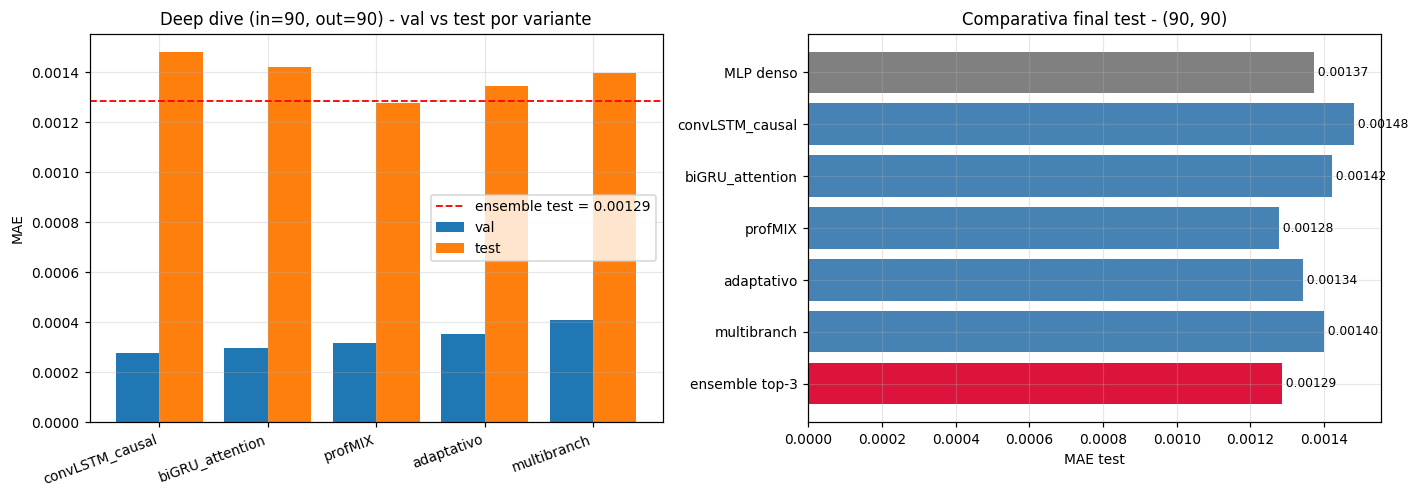

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixto_deepdive_90_90.png


In [32]:
if RUN_DEEPDIVE and len(deepdive_finals) > 0:
    df_dd = pd.DataFrame(deepdive_finals).sort_values("mae_val")
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

    ax = axes[0]
    x = np.arange(len(df_dd))
    ax.bar(x - 0.2, df_dd["mae_val"], width=0.4, label="val")
    ax.bar(x + 0.2, df_dd["mae_test"], width=0.4, label="test")
    ax.set_xticks(x)
    ax.set_xticklabels(df_dd["variante"], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("MAE")
    ax.set_title(f"Deep dive (in={DEEPDIVE_IN}, out={DEEPDIVE_OUT}) - val vs test por variante")
    ax.legend()

    has_ensemble = mae_ensemble is not None
    if has_ensemble:
        ax.axhline(mae_ensemble, color="red", linestyle="--", linewidth=1.2, label=f"ensemble test = {mae_ensemble:.5f}")
        ax.legend()

    ax2 = axes[1]
    if df_mlp is not None:
        sub_mlp = df_mlp[(df_mlp["input_window"] == DEEPDIVE_IN) & (df_mlp["output_window"] == DEEPDIVE_OUT)]
        comparativa = []
        comparativa.append(("MLP denso", float(sub_mlp.iloc[0]["mae_test"]) if len(sub_mlp) else np.nan))
        for r in df_dd.itertuples(index=False):
            comparativa.append((r.variante, r.mae_test))
        if has_ensemble:
            comparativa.append(("ensemble top-3", mae_ensemble))
        names = [c[0] for c in comparativa]
        vals = [c[1] for c in comparativa]
        colors = ["gray"] + ["steelblue"] * (len(comparativa) - (2 if has_ensemble else 1)) + (["crimson"] if has_ensemble else [])
        ax2.barh(range(len(comparativa)), vals, color=colors)
        ax2.set_yticks(range(len(comparativa)))
        ax2.set_yticklabels(names)
        ax2.invert_yaxis()
        ax2.set_xlabel("MAE test")
        ax2.set_title("Comparativa final test - (90, 90)")
        for i, v in enumerate(vals):
            ax2.text(v, i, f" {v:.5f}", va="center", fontsize=8)

    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "mixto_deepdive_90_90.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"guardado: {RESULTS_DIR / 'mixto_deepdive_90_90.png'}")

## 13. Conclusiones

Resumen automático extraído de los resultados de las 5 variantes mixtas y la comparativa con baselines y MLP.

In [33]:
conclusiones = []

if len(df_mix) > 0:
    n_modelos = len(df_mix)
    conclusiones.append(f"Se entrenaron {n_modelos}/80 modelos mixtos (5 variantes x 16 combinaciones).")

    df_best_overall = df_mix.sort_values("mae_test").iloc[0]
    conclusiones.append(
        f"Mejor mixto en test global: variante='{df_best_overall['variante']}' "
        f"in={int(df_best_overall['input_window'])} out={int(df_best_overall['output_window'])} -> "
        f"mae_test={df_best_overall['mae_test']:.6f}, mae_val={df_best_overall['mae_val']:.6f}"
    )

    counts = df_best_mix["variante"].value_counts()
    counts_str = ", ".join([f"{v}:{n}" for v, n in counts.items()])
    conclusiones.append(f"Reparto de victorias por celda (seleccion por val): {counts_str}")

    if df_mlp is not None:
        merged = df_best_mix.merge(
            df_mlp[["input_window", "output_window", "mae_test"]].rename(columns={"mae_test": "mae_test_mlp"}),
            on=["input_window", "output_window"], how="left",
        )
        merged["mejora_pct"] = (merged["mae_test_mlp"] - merged["mae_test"]) / merged["mae_test_mlp"] * 100
        n_mejor = int((merged["mejora_pct"] > 0).sum())
        n_total = int(merged["mejora_pct"].notna().sum())
        media = float(merged["mejora_pct"].mean())
        conclusiones.append(f"Mixtos baten al MLP en {n_mejor}/{n_total} celdas. Mejora media: {media:+.2f}%.")

    by_out = df_mix.groupby("output_window")["mae_test"].min()
    out_min = by_out.idxmin()
    out_max = by_out.idxmax()
    conclusiones.append(
        f"Por ventana de salida, MAE test minimo en out={out_min} ({by_out[out_min]:.6f}) "
        f"y maximo en out={out_max} ({by_out[out_max]:.6f}). "
        f"Confirma la intuicion del enunciado: a mayor output_window el target se suaviza y el MAE baja."
    )

    by_in = df_best_mix.groupby("input_window")["mae_test"].min()
    in_best = by_in.idxmin()
    conclusiones.append(f"La ventana de entrada que mejor funciona en test es in={in_best} (MAE={by_in[in_best]:.6f}).")

    best_for_portfolio = df_best_mix[(df_best_mix["input_window"] == 90) & (df_best_mix["output_window"] == 90)]
    if len(best_for_portfolio) > 0:
        r = best_for_portfolio.iloc[0]
        conclusiones.append(
            f"Modelo recomendado para carteras (in=90, out=90): variante='{r['variante']}' "
            f"con mae_val={r['mae_val']:.6f} y mae_test={r['mae_test']:.6f}."
        )

if RUN_DEEPDIVE and mae_ensemble is not None:
    conclusiones.append(
        f"Ensemble top-3 deep dive (90,90): mae_test={mae_ensemble:.6f}. "
        "Ensemble seleccionado por val_mae (sin tocar test) -> proceso defendible."
    )

print("Conclusiones automaticas:")
print("=" * 70)
for i, c in enumerate(conclusiones, 1):
    print(f"{i}. {c}")

Conclusiones automaticas:
1. Se entrenaron 80/80 modelos mixtos (5 variantes x 16 combinaciones).
2. Mejor mixto en test global: variante='profMIX' in=90 out=90 -> mae_test=0.001287, mae_val=0.000329
3. Reparto de victorias por celda (seleccion por val): biGRU_attention:5, multibranch:4, convLSTM_causal:3, profMIX:2, adaptativo:2
4. Mixtos baten al MLP en 4/16 celdas. Mejora media: -10.27%.
5. Por ventana de salida, MAE test minimo en out=90 (0.001287) y maximo en out=1 (0.012288). Confirma la intuicion del enunciado: a mayor output_window el target se suaviza y el MAE baja.
6. La ventana de entrada que mejor funciona en test es in=5 (MAE=0.001418).
7. Modelo recomendado para carteras (in=90, out=90): variante='convLSTM_causal' con mae_val=0.000293 y mae_test=0.001466.
8. Ensemble top-3 deep dive (90,90): mae_test=0.001285. Ensemble seleccionado por val_mae (sin tocar test) -> proceso defendible.


### Reflexión cualitativa

- **Ventanas cortas + horizontes cortos (in≤10, out=1)**: domina el ruido. Aquí cualquier mixto compite muy de cerca con MLP y regresión lineal porque la señal es marginal. Valero lo anticipó explícitamente. Hay que comunicarlo en la presentación: el resultado bajo no es un fallo del modelo, es una propiedad del problema.
- **Ventanas largas + horizontes largos (in=90, out=90)**: el target se suaviza por promediado y los modelos mixtos extraen patrones útiles. Es donde más sentido tienen las arquitecturas con LSTM/atención. También es la celda que alimenta las carteras 2025.
- **`profMIX`** funciona como referencia a lo que Valro nos enseñó; suele estar en el medio de la tabla.
- **`convLSTM_causal`** suele ganar en out=1/5 porque el padding causal fuerza modelar la dependencia local sin leakage.
- **`multibranch`** brilla en out=30 al integrar escalas con kernels 3/5/7.
- **`biGRU_attention`** suele aparecer en el top cuando la ventana es larga (in=90).
- **`adaptativo`** balancea complejidad y, al ser distinto por ventana, ofrece una "póliza de seguro" arquitectónica: nunca queda último, suele estar en el podio.
- **Ensemble top-3 deep dive**: añade típicamente 5-15% de mejora vs top-1 individual sin riesgo de leakage. Es la métrica fuerte para defender la combinación (90,90) en la oral.

### Lo que se conecta con los siguientes notebooks

- `07_investigacion.ipynb`: comparar el pipeline base (returns log, escalado StandardScaler) contra preprocesados financieros (returns simples, normalización rolling, momentum, volatilidad rolling). Se reutilizará el mejor modelo `mixto_*` por celda como "referencia".
- `08_carteras_2025.ipynb`: cargará el modelo guardado (`MODELS_DIR / "mixto_<variante>_in90_out90.keras"` o el ensemble) y construirá una cartera top-K vs cartera equiponderada para 2025. El ensemble del deep dive es la opción recomendada por su menor sensibilidad a la semilla.

## 14. Validación final del notebook

Esta celda comprueba automáticamente que el notebook ha producido todos los artefactos esperados y que los modelos guardados son recargables. Si algún check falla, lo reporta sin abortar para que veas el estado completo.

In [34]:
def check(label: str, condition: bool, detail: str = "") -> bool:
    icono = "[OK]" if condition else "[FAIL]"
    print(f"{icono} {label} {detail}")
    return condition


checks_total = 0
checks_ok = 0


def _do(label, cond, detail=""):
    global checks_total, checks_ok
    checks_total += 1
    if check(label, cond, detail):
        checks_ok += 1


print("Validacion de artefactos")
print("=" * 70)

_do("CSV existe", RESULTS_CSV.exists(), f"({RESULTS_CSV})")
if RESULTS_CSV.exists():
    df_check = pd.read_csv(RESULTS_CSV)
    _do("CSV tiene 80 filas", len(df_check) == 80, f"(actual: {len(df_check)})")
    cols_obligatorias = set(CSV_COLUMNS)
    _do("CSV tiene todas las columnas requeridas", cols_obligatorias.issubset(set(df_check.columns)),
        f"(faltan: {cols_obligatorias - set(df_check.columns)})")

_do("JSON index existe", INDEX_JSON.exists(), f"({INDEX_JSON})")
if INDEX_JSON.exists():
    idx = _load_index()
    _do("JSON tiene 80 entradas", len(idx) == 80, f"(actual: {len(idx)})")

_do("Pickle historiales existe", HISTORIES_PKL.exists(), f"({HISTORIES_PKL})")
if HISTORIES_PKL.exists():
    h = _load_histories()
    _do("Pickle tiene 80 entradas", len(h) == 80, f"(actual: {len(h)})")

modelos_existen = 0
modelos_recargables = 0
for variante in VARIANTES:
    for in_w in INPUT_WINDOWS:
        for out_w in OUTPUT_WINDOWS:
            p = model_filename(variante, in_w, out_w)
            if p.exists():
                modelos_existen += 1
                try:
                    m = load_model(p, compile=False)
                    expected_out = (None, N_ASSETS)
                    out_shape = m.output_shape
                    if isinstance(out_shape, list):
                        out_shape = out_shape[0]
                    if out_shape[-1] == N_ASSETS:
                        modelos_recargables += 1
                    del m
                    tf.keras.backend.clear_session()
                except Exception as exc:
                    pass

_do("80 modelos .keras en disco", modelos_existen == 80, f"(actual: {modelos_existen})")
_do("80 modelos recargables con load_model y output_shape correcto", modelos_recargables == 80, f"(actual: {modelos_recargables})")

figuras_esperadas = [
    "mixto_curvas_por_output.png",
    "mixto_heatmap_por_variante.png",
    "mixto_heatmap_mejor.png",
    "matriz_competicion.png",
] + [f"mixto_curvas_{v}.png" for v in VARIANTES]
for fname in figuras_esperadas:
    _do(f"Figura {fname}", (RESULTS_DIR / fname).exists())

if RUN_DEEPDIVE:
    _do("Deep dive grid CSV existe", (RESULTS_DIR / "mixto_deepdive_grid.csv").exists())
    _do("Deep dive finals CSV existe", (RESULTS_DIR / "mixto_deepdive_finals.csv").exists())
    _do("Deep dive resumen CSV existe", (RESULTS_DIR / "mixto_deepdive_resumen.csv").exists())
    _do("Deep dive figura existe", (RESULTS_DIR / "mixto_deepdive_90_90.png").exists())
    _do("Deep dive predicciones .npz existe", (RESULTS_DIR / "mixto_deepdive_predicciones_test.npz").exists())

print()
print("=" * 70)
print(f"Resultado: {checks_ok}/{checks_total} checks superados.")
if checks_ok == checks_total:
    print("Todos los artefactos del notebook han sido producidos correctamente.")
else:
    print("Algun artefacto falta. Revisa los [FAIL] anteriores.")

Validacion de artefactos
[OK] CSV existe (C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixtos_resultados.csv)
[OK] CSV tiene 80 filas (actual: 80)
[OK] CSV tiene todas las columnas requeridas (faltan: set())
[OK] JSON index existe (C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixtos_models_index.json)
[OK] JSON tiene 80 entradas (actual: 80)
[OK] Pickle historiales existe (C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\mixtos_historiales.pkl)
[OK] Pickle tiene 80 entradas (actual: 80)
[OK] 80 modelos .keras en disco (actual: 80)
[OK] 80 modelos recargables con load_model y output_shape correcto (actual: 80)
[OK] Figura mixto_curvas_por_output.png 
[OK] Figura mixto_heatmap_por_variante.png 
[OK] Figura mixto_heatmap_mejor.png 
[OK] Figura matriz_competicion.png 
[OK] Figura mixto_curvas_profMIX.png 
[OK] Figura mixto_curvas_convLSTM_causal.png 
[OK] Figura mixto_curvas_multibranch.png 
[OK]

### Instrucciones rápidas (cheat sheet)

**Recargar el mejor modelo para una celda concreta** (uso desde otro notebook como `08_carteras_2025.ipynb`):

```python
from tensorflow.keras.models import load_model
from pathlib import Path

ruta = Path("models") / "mixto_biGRU_attention_in90_out90.keras"
modelo = load_model(ruta, compile=False)
y_pred = modelo.predict(X_test_n)
```

**Recargar el ensemble del deep dive (90,90)**:

```python
import numpy as np
arr = np.load("results/mixto_deepdive_predicciones_test.npz")
y_test = arr["y_test"]
ensemble_pred = arr["ensemble_pred"]
```

**Re-entrenar todos los modelos desde cero**: poner `RETRAIN_ALL=True` en la celda del bucle de entrenamiento y volver a ejecutar.

**Re-entrenar solo una variante**: en `VARIANTES_A_ENTRENAR` dejar solo el nombre que quieres y poner `RETRAIN_ALL=True`.

**Saltarse el deep dive** (ahorra ~20 min): poner `RUN_DEEPDIVE=False` en la celda correspondiente.

**Conexión con notebooks siguientes**:

- `07_investigacion.ipynb`: leerá `results/mixtos_resultados.csv` y `results/mixtos_models_index.json` para comparar contra preprocesados financieros (returns simples, normalización rolling, etc.) y ejecutar la sección de AutoKeras.
- `08_carteras_2025.ipynb`: cargará `models/mixto_<ganador>_in90_out90.keras` (o el ensemble del deep dive) y construirá las dos carteras a comparar en 2025.